# **Evidencia 5. Construcción de los tableros**

**Analítica de datos y herramientas de inteligencia artificial (Gpo 601)**

- Jorge Emiliano Gómez Hernández | A01368016
- Jaime Trujillo Ruiz | A01276139
- Lisy León Rubio | A01369783
- Montserrat Hernández Pérez | A01276367

## **1.Diseño del Prototipo**

---
* **Enlace a prototipo de tablero (Figma):** https://www.figma.com/design/BkcGOJpJu33XVYLwqukqpo/Reto-CNH--Dise%C3%B1o-UI?node-id=21052-2054&t=3CxQgvZkhk7VrjZa-1

---
A continuación, se detalla el análisis de los componentes del prototipo del tablero:

### **1.1 Estructura y diseño**

La versión más reciente que tenemos del dashboard, tiene una primera área interactiva en donde el usuario sube 4 archivos excel (Population View, Horas 2024–2025, Mantenimientos y Unidades Día Anterior) para proceder a darle clic al botón 'Procesar y lanzar Dashboard'.

Una vez terminada la carga, el usuario puede ver la primera pantalla, donde en la parte lateral izquierda se muestra una barra que servirá como 'menú' para facilitar la navegación entre las diferentes secciones del dashboard. En cada página correspondiente a cada sección, se muestran gráficas interactivas (con la librería dash), además de tablas donde se pueden visualizar datos importantes.

También es necesario mencionar que se agregó un mapa donde se puede ver la localización geográfica de cada unidad activa.

---

### **1.2 Paleta de colores**

La paleta de colores se eligió con base en lo que José Bravo mencionó en la primera sesión: que el tablero tuviera una interfaz parecida a la plataforma 'Control Room', usando colores parecidos, con la intención de lograr una mayor facilidad de entendimiento por parte de ellos. Además, se consideraron las reglas de visualización vistas en la Unidad de Formación 5.

De esta manera, se tomó el rojo oscuro como el color base para la interfaz de la página web, siguiendo el color que se presenta en los logos de CNH Global. Por otro lado, para las gráficas se optó por utilizar colores diversos, siguiendo los significados asociados a cada color, es decir, el verde para lo relacionado a lo que está en orden o dentro del parámetro, el rojo para resaltar datos que representan una alarma, el amarillo para resaltar advertencias y el azul para representar datos de manera neutral. Así mismo, para las gráficas que muestran datos de un mismo grupo, como es el caso del comportamiento de los distribuidores, se optó por utilizar una paleta monocromática para indicar que todos pertenecen al mismo grupo.

---

### **1.3 Flujo de usuario**

Para nuestra versión casi final de nuestro dashboard, se cuenta con una primera pantalla donde se cargan los archivos excel de 4 bases de datos (Population View, Horas 2024–2025, Mantenimientos y Unidades Día Anterior) para proceder a 'Procesar y lanzar Dashboard'.

Después, se abre una nueva página, donde se puede visualizar la primera sección: 'Overview', donde se muestran los datos generales de la flotilla de unidades que están activas y donde se puede ver su localización en un mapa. Además, se muestra una barra lateral izquierda donde se puede acceder a cada una de las secciones, mismas que se explicarán a continuación:

En la siguiente sección: 'Agricultura', se puede ver información y gráficas relevantes para el insight que desarrollamos: "El calendario agrícola debe usarse para priorizar esfuerzo, no para decidir binariamente".

En la siguiente sección: 'Distribuidores', se puede ver información y gráficas relevantes para el insight que desarrollamos: "Cuatro distribuidores concentran el 60% de la sobrecarga proyectada
el próximo mes". Respecto a este insight y sección, fue desarrollada antes de que se recibieran las correcciones de los insights, por lo que posteriormente se eliminará para sólo mantener 3 insights.

En la siguiente sección: 'Retención', se puede ver información y gráficas relevantes para el insight que desarrollamos: "El umbral de las 600 horas es el punto de quiebre definitivo de la relación aftermarket".


## **2.Storytelling del Tablero (Narrativa de Datos)**

---
* **Enlace a video de explicación:**

---

## **3.Desarrollo de Visualizaciones en Notebook**

In [ ]:
!pip install scipy scikit-learn statsmodels xgboost --quiet

In [ ]:
!pip install plotly -qq

In [ ]:
# ── IMPORTACIONES ──────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML
from plotly.subplots import make_subplots
import warnings

from scipy.stats import f_oneway
from scipy import stats
import statsmodels.api as sm
import statistics

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score
)
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

C_CRIMSON = '#9B1B30'
C_RED     = '#E63946'
C_CORAL   = '#F4A261'
C_GOLD    = '#E9C46A'
C_TEAL    = '#2A9D8F'
C_BLUE    = '#264653'
C_SLATE   = '#457B9D'
C_NAVY    = '#1B2A4A'
C_GRAY    = '#6B7280'
C_LGRAY   = '#F3F4F6'
C_WHITE   = '#FFFFFF'
C_GREEN   = '#2CAC64'
FONT      = 'Arial, sans-serif'

def base_layout(title_text, subtitle_text=None, h=460):
    layout = dict(
        title=dict(
            text=f"<b>{title_text}</b>",
            font=dict(size=20, family=FONT, color=C_NAVY),
            x=0.03, y=0.97, xanchor='left'
        ),
        paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
        height=h, font_family=FONT,
        margin=dict(t=90, b=70, l=70, r=60),
        legend=dict(orientation='h', y=-0.18, x=0,
                    font=dict(size=12, family=FONT),
                    bgcolor='rgba(0,0,0,0)', bordercolor='rgba(0,0,0,0)')
    )
    if subtitle_text:
        layout['title']['subtitle'] = dict(
            text=subtitle_text,
            font=dict(size=13, family=FONT, color=C_GRAY))
    return layout

In [ ]:
# ── GOOGLE DRIVE ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DIR = '/content/drive/MyDrive/RETO_CNH/0_Bases de Datos/2_limpios'
os.chdir(DIR)

In [ ]:
# Para cargar tablas mantenimientos y Unidades DA
mant = pd.read_excel('Mantenimientos_2024_2025_limpio.xlsx')
uda  = pd.read_excel('Unidades_dia_anterior_limpio.xlsx')

print(f'Mantenimientos 2024-2025 : {mant.shape[0]:,} filas  |  {mant.shape[1]} columnas')
print(f'Unidades día anterior    : {uda.shape[0]:,} filas  |  {uda.shape[1]} columnas')

Mantenimientos 2024-2025 : 6,775 filas  |  10 columnas
Unidades día anterior    : 10,844 filas  |  30 columnas


In [ ]:
# CARGA Y PREPARACIÓN
mant = pd.read_excel('Mantenimientos_2024_2025_limpio.xlsx')
unid = pd.read_excel('Unidades_dia_anterior_limpio.xlsx')
h25  = pd.read_excel('Horas_2025_limpio.xlsx')

MARCAS = ['NEW HOLLAND AG', 'CASE IH']
total_raw = len(unid)
mant = mant[mant['marca'].isin(MARCAS)].copy()
unid = unid[unid['marca'].isin(MARCAS)].copy()
h25  = h25[h25['alias'].isin(unid['alias'].unique())].copy()

mant['fecha']     = pd.to_datetime(mant['fecha'],    errors='coerce')
mant['horometro'] = pd.to_numeric(mant['horometro'], errors='coerce')
mant['actual']    = pd.to_numeric(mant['actual'],    errors='coerce')
unid['horometro'] = pd.to_numeric(unid['horometro'], errors='coerce')
mant['cumplimiento'] = mant['estatus'].isin(['Cerrada','PorVencer','EnProceso']).astype(int)
mant['abandono']     = 1 - mant['cumplimiento']
mant['mes_num']      = mant['fecha'].dt.month
nombres_mes = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
mant['mes'] = mant['mes_num'].map(nombres_mes)
mant['diff_hrs'] = (mant['actual'] - mant['horometro']).abs()

zona_sader = {
    'Baja California':'Noroeste','Baja California Sur':'Noroeste','Sonora':'Noroeste',
    'Sinaloa':'Noroeste','Nayarit':'Noroeste',
    'Chihuahua':'Noreste','Coahuila':'Noreste','Durango':'Noreste',
    'Nuevo León':'Noreste','Tamaulipas':'Noreste','Zacatecas':'Noreste',
    'San Luis Potosí':'Noreste',
    'Jalisco':'Centro Occidente','Michoacán':'Centro Occidente',
    'Colima':'Centro Occidente','Aguascalientes':'Centro Occidente',
    'Guanajuato':'Centro Occidente','Querétaro':'Centro Occidente',
    'Ciudad de México':'Centro','Estado de México':'Centro',
    'Hidalgo':'Centro','Morelos':'Centro','Puebla':'Centro','Tlaxcala':'Centro',
    'Veracruz':'Sur-Sureste','Oaxaca':'Sur-Sureste','Chiapas':'Sur-Sureste',
    'Tabasco':'Sur-Sureste','Campeche':'Sur-Sureste','Yucatán':'Sur-Sureste',
    'Quintana Roo':'Sur-Sureste','Guerrero':'Sur-Sureste',
}
df = mant.merge(unid[['alias','estado','c_fuera','cerrados','pendientes']], on='alias', how='left')
df['zona'] = df['estado'].map(zona_sader).fillna('Otras')
h25['ritmo_3m'] = h25[['hrs_2025_10','hrs_2025_11','hrs_2025_12']].mean(axis=1)

orden_zonas = ['Noroeste','Centro Occidente','Centro','Sur-Sureste','Noreste']
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

print(f"✅ {len(mant):,} mantenimientos | {len(unid):,} unidades | {total_raw:,} flota total")


✅ 6,636 mantenimientos | 9,845 unidades | 10,844 flota total


#### **Preparación de variables para los gráficos de cada insight**

In [ ]:
# Para Insight 3: Agrupación de zonas geográficas SADER

mapa_estado_zona = {
    # Noroeste — agricul detura de riego tecnificado
    'Baja California'    : 'Noroeste',
    'Baja California Sur': 'Noroeste',
    'Sonora'             : 'Noroeste',
    'Sinaloa'            : 'Noroeste',
    'Nayarit'            : 'Noroeste',

    # Noreste — agricultura intensiva y forrajera
    'Chihuahua'              : 'Noreste',
    'Coahuila de Zaragoza'   : 'Noreste',
    'Durango'                : 'Noreste',
    'Nuevo Leon'             : 'Noreste',
    'Tamaulipas'             : 'Noreste',
    'Zacatecas'              : 'Noreste',

    # Centro Occidente — alta producción y exportación
    'Aguascalientes'     : 'Centro Occidente',
    'Colima'             : 'Centro Occidente',
    'Guanajuato'         : 'Centro Occidente',
    'Jalisco'            : 'Centro Occidente',
    'Michoacan de Ocampo': 'Centro Occidente',
    'San Luis Potosi'    : 'Centro Occidente',

    # Centro — temporal y cultivos mixtos
    'Distrito Federal'   : 'Centro',
    'Mexico'             : 'Centro',
    'Guerrero'           : 'Centro',
    'Hidalgo'            : 'Centro',
    'Morelos'            : 'Centro',
    'Puebla'             : 'Centro',
    'Queretaro'          : 'Centro',
    'Tlaxcala'           : 'Centro',

    # Sur-Sureste — potencial tropical, caña, maíz
    'Campeche'                        : 'Sur-Sureste',
    'Chiapas'                         : 'Sur-Sureste',
    'Oaxaca'                          : 'Sur-Sureste',
    'Quintana Roo'                    : 'Sur-Sureste',
    'Tabasco'                         : 'Sur-Sureste',
    'Veracruz de Ignacio de la Llave' : 'Sur-Sureste',
    'Yucatan'                         : 'Sur-Sureste',
}

# Agregar zona al dataframe de unidades
uda['zona'] = uda['estado'].map(mapa_estado_zona)

print('Unidades por zona (desde el estado registrado en el dataset):')
print()
print(uda['zona'].value_counts())

Unidades por zona (desde el estado registrado en el dataset):

zona
Centro Occidente    3183
Centro              2711
Sur-Sureste         1308
Noreste             1258
Noroeste            1180
Name: count, dtype: int64


In [ ]:
# Para hacer JOIN MANTENIMIENTOS + ZONA
# Unimos la tabla de mantenimientos con la zona de cada unidad
# usando el campo 'alias' como llave de unión.
# Esto nos permite saber en qué zona del país se realizó (o no) cada servicio.

zona_por_alias = uda[['alias', 'zona']].dropna().drop_duplicates(subset='alias')

mant = mant.merge(zona_por_alias, on='alias', how='left')

print(f'Registros de mantenimientos con zona asignada: {mant["zona"].notna().sum():,} de {len(mant):,}')
print()
print('Registros por zona:')
print(mant['zona'].value_counts())

Registros de mantenimientos con zona asignada: 6,556 de 6,636

Registros por zona:
zona
Centro Occidente    2173
Centro              1745
Noroeste             903
Sur-Sureste          884
Noreste              851
Name: count, dtype: int64


In [ ]:
# Para Insight 3: Filtrado de marcas agrícolas de CNH en tabla de Unidades DA
uda_clean = uda[
    uda['marca'].isin(['NEW HOLLAND AG', 'CASE IH'])
].copy()

uda_clean['tiene_pendientes'] = (uda_clean['pendientes'] > 0).astype(int)

print(f'Unidades totales en el dataset   : {len(uda):,}')
print(f'Unidades NEW HOLLAND AG + CASE IH: {len(uda_clean):,}')
print(f'Unidades con al menos 1 pendiente: {uda_clean["tiene_pendientes"].sum():,}')

Unidades totales en el dataset   : 10,844
Unidades NEW HOLLAND AG + CASE IH: 9,845
Unidades con al menos 1 pendiente: 6,884


In [ ]:
# Para cargar la tabla de horas 2024 y 2025
h24 = pd.read_excel('Horas_2024_limpio.xlsx')
h25 = pd.read_excel('Horas_2025_limpio.xlsx')

print(f'Horas 2024: {h24.shape[0]:,} filas  |  {h24.shape[1]} columnas')
print(f'Horas 2025: {h25.shape[0]:,} filas  |  {h25.shape[1]} columnas')

Horas 2024: 9,108 filas  |  19 columnas
Horas 2025: 9,835 filas  |  16 columnas


### **INSIGHT 1**: El umbral de las 600 horas es el punto de quiebre definitivo de la relación aftermarket (Descriptiva 1)

In [ ]:
import pandas as pd
import numpy as np

# ── PREPARACIÓN: CUMPLIMIENTO DE MANTENIMIENTOS ──────────────────────────────────
cols_mant = [
    'mant_50', 'mant_300', 'mant_600', 'mant_900',
    'mant_1200', 'mant_1500', 'mant_1800', 'mant_2100', 'mant_2400'
]

def codificar(v):
    """0 = cumplió (Cerrada), 1 = incumplió, NaN = no aplica."""
    if pd.isna(v):
        return np.nan
    if v == 'Cerrada':
        return 0
    if v in ['Pendiente', 'CerradaFuera', 'PorVencer', 'EnProceso', 'Abierta']:
        return 1
    return np.nan

uda_d1 = uda[['alias'] + cols_mant].copy()
bin_cols = []
for c in cols_mant:
    col_bin = c + '_bin'
    uda_d1[col_bin] = uda_d1[c].map(codificar)
    bin_cols.append(col_bin)

# Tasa de incumplimiento acumulada por intervalo
print('Tasa de incumplimiento por intervalo:')
print()
tasa_incumplimiento = []
for col_bin, nombre in zip(bin_cols, cols_mant):
    n    = uda_d1[col_bin].notna().sum()
    tasa = uda_d1[col_bin].mean()
    tasa_incumplimiento.append({'intervalo': nombre, 'n': n, 'tasa_incumple': tasa})
    print(f'  {nombre:<12}: n={n:>5,}   incumplimiento = {tasa:.1%}')

df_tasa = pd.DataFrame(tasa_incumplimiento)
df_tasa['n_incumplieron'] = (df_tasa['tasa_incumple'] * df_tasa['n']).round(0).astype(int)
df_tasa['n_cumplieron']   = df_tasa['n'] - df_tasa['n_incumplieron']
# Agrega esta línea donde calculas las columnas derivadas de df_tasa
df_tasa['tasa_cumple'] = 1 - df_tasa['tasa_incumple']

# Tasa de RETORNO al siguiente intervalo dado que incumplió el anterior
print()
print('Tasa de retorno al siguiente servicio tras incumplir:')
print()
pares = []
for i in range(len(bin_cols) - 1):
    col_i   = bin_cols[i]
    col_ip1 = bin_cols[i + 1]
    sub     = uda_d1[[col_i, col_ip1]].dropna()
    incumplieron = sub[sub[col_i] == 1]
    if len(incumplieron) > 0:
        tasa_retorno = (incumplieron[col_ip1] == 0).mean()
    else:
        tasa_retorno = np.nan
    pares.append({
        'intervalo':      cols_mant[i],
        'n_incumplieron': len(incumplieron),
        'tasa_retorno':   tasa_retorno
    })
    print(f'  Tras incumplir {cols_mant[i]:<12}: '
          f'n={len(incumplieron):>5,}   retornan = {tasa_retorno:.1%}')

df_pares = pd.DataFrame(pares)

# ── Columnas derivadas para df_pares (van DESPUÉS de crear el DataFrame) ─────
df_pares['n_retornaron']    = (df_pares['tasa_retorno'] * df_pares['n_incumplieron']).round(0).astype(int)
df_pares['n_no_retornaron'] = df_pares['n_incumplieron'] - df_pares['n_retornaron']

Tasa de incumplimiento por intervalo:

  mant_50     : n=6,829   incumplimiento = 46.8%
  mant_300    : n=5,912   incumplimiento = 58.4%
  mant_600    : n=4,939   incumplimiento = 68.0%
  mant_900    : n=4,102   incumplimiento = 75.4%
  mant_1200   : n=3,307   incumplimiento = 80.0%
  mant_1500   : n=2,650   incumplimiento = 83.2%
  mant_1800   : n=2,071   incumplimiento = 86.0%
  mant_2100   : n=1,593   incumplimiento = 90.3%
  mant_2400   : n=1,202   incumplimiento = 93.0%

Tasa de retorno al siguiente servicio tras incumplir:

  Tras incumplir mant_50     : n=2,353   retornan = 10.2%
  Tras incumplir mant_300    : n=2,517   retornan = 6.0%
  Tras incumplir mant_600    : n=2,531   retornan = 4.9%
  Tras incumplir mant_900    : n=2,339   retornan = 5.0%
  Tras incumplir mant_1200   : n=2,043   retornan = 4.1%
  Tras incumplir mant_1500   : n=1,658   retornan = 3.6%
  Tras incumplir mant_1800   : n=1,317   retornan = 2.9%
  Tras incumplir mant_2100   : n=1,049   retornan = 2.3%


#### **>Visualización 1**: Tasa de incumplimiento por intervalo de servicios de mantenimientos



In [ ]:
fig1 = go.Figure()

# ── Barra verde (cumplimiento) ────────────────────────────────────────────────
fig1.add_trace(go.Bar(
    y=df_tasa['intervalo'],
    x=[1.0] * len(df_tasa),
    orientation='h',
    marker=dict(color=C_TEAL, line=dict(color=C_WHITE, width=1)),
    text=[f"{1 - row['tasa_incumple']:.1%} cumple" for _, row in df_tasa.iterrows()],
    textposition='outside',           # ← fuera siempre, sin cortes
    textfont=dict(size=12, family=FONT, color=C_TEAL),
    customdata=df_tasa[['n_cumplieron', 'tasa_cumple', 'n']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Tasa de cumplimiento: <b>%{customdata[1]:.1%}</b><br>'   # ← se calcula en hover
        'Unidades con dato registrado: <b>%{customdata[2]:,}</b><br>'
        '🟢 Unidades que cumplieron: <b>%{customdata[0]:,}</b>'
        '<extra></extra>'
    ),
    name='Cumplimiento',
    showlegend=False,
))

# ── Barra roja (incumplimiento) ───────────────────────────────────────────────
fig1.add_trace(go.Bar(
    y=df_tasa['intervalo'],
    x=df_tasa['tasa_incumple'],
    orientation='h',
    marker=dict(color=C_CRIMSON, line=dict(color=C_WHITE, width=1)),
    text=[f"<b>{v:.1%}</b> incumple" for v in df_tasa['tasa_incumple']],
    textposition='inside',
    insidetextanchor='end',
    textfont=dict(size=13, family=FONT, color=C_WHITE),
    customdata=df_tasa[['n', 'tasa_incumple', 'n_incumplieron']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Tasa de incumplimiento: <b>%{customdata[1]:.1%}</b><br>'
        'Unidades con dato registrado: <b>%{customdata[0]:,}</b><br>'
        '🔴 Unidades que incumplieron: <b>%{customdata[2]:,}</b>'
        '<extra></extra>'
    ),
    name='Incumplimiento',
    showlegend=False,
))

fig1.update_layout(
    title=dict(
        text='<b>Tasa de incumplimiento / cumplimiento por intervalo de servicio</b>',
        font=dict(size=18, family=FONT, color=C_NAVY),
        x=0.45, xanchor='center'
    ),
    barmode='overlay',
    xaxis=dict(
        tickformat='.0%',
        range=[0, 1.18],              # ← espacio extra para texto fuera
        showgrid=False,
        zeroline=False,
        showticklabels=False,
    ),
    yaxis=dict(
        tickfont=dict(size=12, family=FONT, color=C_NAVY),
        showgrid=False,
        autorange='reversed',
    ),
    paper_bgcolor=C_WHITE,
    plot_bgcolor=C_WHITE,
    height=420,
    width=710,
    margin=dict(t=60, b=40, l=80, r=100),  # ← margen derecho para el texto
    font_family=FONT,
)

fig1.show()

Esta gráfica de barras, permite visualizar la diferencia del comportamiento del incumplimiento de cada intervalo de servicio. Este incumplimiento se comporta de manera creciente, es decir, mientras más horas de operación tenga la unidad, más probable es que no cumpla con sus servicios.

#### **>Visualización 2**: Tasa de retorno al siguiente servicio tras incumplir el anterior

In [ ]:
colores_ret = [C_CRIMSON if v < 0.05 else C_TEAL for v in df_pares['tasa_retorno']]

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=df_pares['intervalo'],
    y=df_pares['tasa_retorno'],
    marker=dict(color=colores_ret, line=dict(color=C_WHITE, width=1.5)),
    text=[f"<b>{v:.1%}</b>" for v in df_pares['tasa_retorno']],
    textposition='outside',
    textfont=dict(size=15, family=FONT,
                  color=[C_CRIMSON if v < 0.05 else C_TEAL
                         for v in df_pares['tasa_retorno']]),
    customdata=df_pares[['n_incumplieron', 'tasa_retorno', 'n_retornaron', 'n_no_retornaron']].values,
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Tasa de retorno al siguiente servicio: <b>%{customdata[1]:.1%}</b><br>'
        'Unidades que incumplieron y tienen dato del siguiente intervalo: <b>%{customdata[0]:,}</b><br>'
        '🟢 Unidades que retornaron al siguiente servicio: <b>%{customdata[2]:,}</b><br>'
        '🔴 Unidades que no retornaron al siguiente servicio: <b>%{customdata[3]:,}</b>'
        '<extra></extra>'
    ),
    showlegend=False,
))

# Línea umbral 5%
fig2.add_hline(
    y=0.05,
    line=dict(color=C_NAVY, width=1.5, dash='dot'),
    annotation_text='<b>Umbral 5% — criterio operativo de negocio</b>',
    annotation_position='top right',
    annotation_font=dict(size=12, color=C_NAVY, family=FONT),
)
fig2.add_annotation(
    text=(
        '''<i>El umbral del 5% fue definido como criterio operativo de negocio, representa el nivel por debajo del cual <br> la tasa de retorno indica una pérdida estructural del cliente que no es recuperable fácilmente</i>'''
    ),
    xref='paper', yref='paper',
    x=0.5, y=-0.32,
    showarrow=False,
    font=dict(size=15, color=C_GRAY, family=FONT),
    align='center',
)

fig2.update_layout(
    title=dict(
        text='<b>Tasa de retorno al siguiente servicio,<br>tras incumplir el intervalo</b>',
        font=dict(size=18, family=FONT, color=C_NAVY),
        x=0.5, xanchor='center',
        y=0.8 # Adjusted title position
    ),
    xaxis=dict(tickangle=-40, tickfont=dict(size=13)),
    yaxis=dict(
        tickformat='.0%',
        range=[0, 0.24],
        gridcolor=C_LGRAY,
        zeroline=False,
        title_text='Tasa de retorno al siguiente servicio',
    ),
    paper_bgcolor=C_WHITE,
    plot_bgcolor=C_WHITE,
    height=500,
    width=1200,
    margin=dict(t=80, b=100, l=60, r=60),
    bargap=0.3,
    font_family=FONT,
)

fig2.show()

Esta gráfica de barras está ligada a la anterior y permite visualizar la tasa de retorno que tienen los servicios, al haberse incumplido el servicio anterior. La intención de este gráfico es que se identifique el punto de quiebre de la relación aftermarket con el cliente, el cuál es el mantenimiento 600.

### **INSIGHT 2**: El segundo servicio externo es el punto de no retorno: la ventana de recuperación se cierra en la primera fuga (Diagnóstica 4)

Importación de las librerias

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### **>Visualización 3**: Probabilidad de retorno con servicios externos

In [ ]:
# ── DIAG 4: CONSTRUCCIÓN DE VARIABLES CON SEPARACIÓN TEMPORAL ────────────────

cols_intervalos = [
    'mant_50', 'mant_300', 'mant_600', 'mant_900',
    'mant_1200', 'mant_1500', 'mant_1800', 'mant_2100', 'mant_2400'
]

cols_disponibles = [c for c in cols_intervalos if c in uda.columns]

resultados_dx4 = []

for _, row in uda.iterrows():
    servicios = [(col, row[col]) for col in cols_disponibles if pd.notna(row[col])]

    if len(servicios) == 0:
        continue

    fuera_encontrados = 0
    corte_idx = None
    for i, (col, estatus) in enumerate(servicios):
        if estatus == 'CerradaFuera':
            fuera_encontrados += 1
            if fuera_encontrados == 2:
                corte_idx = i
                break

    if corte_idx is not None:
        posteriores = servicios[corte_idx + 1:]
        retorno = int(any(e == 'Cerrada' for _, e in posteriores))
        grupo = 1
        n_fuera_previo = fuera_encontrados  # siempre 2 en este caso
    else:
        retorno = int(any(e == 'Cerrada' for _, e in servicios))
        grupo = 0
        # ── NUEVO: contar cuántos CerradaFuera tuvo (0 o 1) ──────────────
        n_fuera_previo = sum(1 for _, e in servicios if e == 'CerradaFuera')

    resultados_dx4.append({
        'alias':               row.get('alias', None),
        'tuvo_2_fuera_previo': grupo,
        'n_fuera_previo':      n_fuera_previo,   # ← campo nuevo
        'n_servicios_total':   len(servicios),
        'horometro_corte':     row.get('horometro', np.nan),
        'retorno_posterior':   retorno
    })

df_dx4 = pd.DataFrame(resultados_dx4)

# ── NUEVO: segmentación en 3 grupos para visualización ───────────────────────
df_dx4['grupo_3'] = df_dx4['n_fuera_previo'].apply(
    lambda x: '0 externos' if x == 0 else ('1 externo' if x == 1 else '≥2 externos')
)

print(f'Unidades analizadas: {len(df_dx4):,}')
print()

# ── Resumen por los 3 grupos ──────────────────────────────────────────────────
orden_print = ['0 externos', '1 externo', '≥2 externos']
resumen_print = (
    df_dx4.groupby('grupo_3')['retorno_posterior']
    .agg(n_total='count', n_retornaron='sum')
    .reindex(orden_print)
    .reset_index()
)
resumen_print['tasa_retorno']    = resumen_print['n_retornaron'] / resumen_print['n_total']
resumen_print['n_no_retornaron'] = resumen_print['n_total'] - resumen_print['n_retornaron']

print('Unidades por grupo (3 segmentos):')
print()
for _, row in resumen_print.iterrows():
    print(f"  {row['grupo_3']:<18}: "
          f"n total = {row['n_total']:>5,}  |  "
          f"retornaron = {row['n_retornaron']:>4,}  |  "
          f"no retornaron = {row['n_no_retornaron']:>4,}  |  "
          f"tasa retorno = {row['tasa_retorno']:.1%}")

Unidades analizadas: 8,015

Unidades por grupo (3 segmentos):

  0 externos        : n total = 5,892  |  retornaron = 3,080  |  no retornaron = 2,812  |  tasa retorno = 52.3%
  1 externo         : n total =   789  |  retornaron =  514  |  no retornaron =  275  |  tasa retorno = 65.1%
  ≥2 externos       : n total = 1,334  |  retornaron =  162  |  no retornaron = 1,172  |  tasa retorno = 12.1%


In [ ]:
if 'grupo_3' not in df_dx4.columns:
    df_dx4['grupo_3'] = df_dx4['n_fuera_previo'].apply(
        lambda x: '0 externos' if x == 0 else ('1 externo' if x == 1 else '≥2 externos')
    )

# ── Métricas por grupo_3 ──────────────────────────────────────────────────────
orden_grupos = ['0 externos', '1 externo', '≥2 externos']

resumen_grupos = (
    df_dx4.groupby('grupo_3')['retorno_posterior']
    .agg(n_total='count', n_retornaron='sum')
    .reindex(orden_grupos)
    .reset_index()
)
resumen_grupos['tasa_retorno']    = resumen_grupos['n_retornaron'] / resumen_grupos['n_total']
resumen_grupos['n_no_retornaron'] = resumen_grupos['n_total'] - resumen_grupos['n_retornaron']

# ── INS-02 | GRÁFICA HORIZONTAL CON DATOS REALES ─────────────────────────────

# Etiquetas con contexto para el eje Y
etiquetas_y = [
    'Sin servicios externos',
    '1 servicio externo<br><sup style="color:#E9A820">↑ Ventana de intervención</sup>',
    '≥2 servicios externos<br><sup style="color:#A20503">▲ Punto de no retorno</sup>',
]

colores_barras = [C_TEAL, C_GREEN, C_RED]

tasas_reales  = resumen_grupos['tasa_retorno'].values * 100  # a porcentaje
# Ajuste manual solicitado: 65.1 -> 65.2
tasas_reales[1] = 65.2

n_totales     = resumen_grupos['n_total'].values
n_retornaron  = resumen_grupos['n_retornaron'].values
n_no_ret      = resumen_grupos['n_no_retornaron'].values

fig_ins02 = go.Figure()

# ── Track gris de fondo (100%) ────────────────────────────────────────────────
fig_ins02.add_trace(go.Bar(
    y=etiquetas_y,
    x=[100, 100, 100],
    orientation='h',
    marker=dict(color='#E5E7EB'),
    showlegend=False,
    hoverinfo='skip',
))

# ── Barras de retorno con datos reales ────────────────────────────────────────
fig_ins02.add_trace(go.Bar(
    y=etiquetas_y,
    x=tasas_reales,
    orientation='h',
    marker=dict(color=colores_barras, line=dict(color=C_WHITE, width=2)),
    text=[f'<b>{t:.1f}%</b>' for t in tasas_reales],
    textposition='outside',
    textfont=dict(size=18, family=FONT, color=colores_barras),
    customdata=list(zip(tasas_reales, n_totales, n_retornaron, n_no_ret)),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Tasa de retorno a red CNH: <b>%{customdata[0]:.1f}%</b><br>'
        'Total de unidades en el grupo: <b>%{customdata[1]:,}</b><br>'
        '🟢 Unidades que retornaron: <b>%{customdata[2]:,}</b><br>'
        '🔴 Unidades que no retornaron: <b>%{customdata[3]:,}</b>'
        '<extra></extra>'
    ),
    showlegend=False,
))

# ── Línea vertical: nivel "1 externo" (ventana de recuperación) ───────────────
fig_ins02.add_vline(
    x=float(tasas_reales[1]),
    line=dict(color=C_NAVY, width=1.5, dash='dot'),
)

# ── Línea vertical: nivel "≥2 externos" (punto de no retorno) ────────────────
fig_ins02.add_vline(
    x=float(tasas_reales[2]),
    line=dict(color=C_RED, width=1.5, dash='dash'),
)

# ── Flecha: caída de 1 externo a ≥2 externos ─────────────────────────────────
fig_ins02.add_annotation(
    x=float(tasas_reales[1]), y=1,
    ax=float(tasas_reales[2]), ay=1,
    xref='x', yref='y', axref='x', ayref='y',
    text='',
    showarrow=True,
    arrowhead=2, arrowsize=1.2, arrowwidth=2.5, arrowcolor=C_CRIMSON,
)

# ── Caja de texto: ventana de recuperación ───────────────────────────────────
caida_pp = round(float(tasas_reales[1]) - float(tasas_reales[2]), 1)
fig_ins02.add_annotation(
    x=float(tasas_reales[2]) + 13, y=0.15,
    xref='x', yref='paper',
    text=(
        f'<b>Ventana de recuperación:</b><br>'
        f'aquí el cliente todavía es recuperable.<br>'
        f'Caída de <b>{caida_pp:.1f}pp</b> al cruzar al 2do externo.'
    ),
    showarrow=False,
    font=dict(size=12, color=C_CRIMSON, family=FONT),
    align='left',
    bgcolor='rgba(255,240,240,0.92)',
    bordercolor=C_CRIMSON,
    borderwidth=1, borderpad=7,
    xanchor='left',
)

# ── LAYOUT ────────────────────────────────────────────────────────────────────
fig_ins02.update_layout(
    title=dict(
        text='<b>Tasa de retorno posterior a servicios externos</b>',
        subtitle=dict(
            text='El comportamiento del cliente indica el retorno — El 2do servicio externo cierra la ventana',
            font=dict(size=16, family=FONT, color=C_GRAY)
        ),
        font=dict(size=20, family=FONT, color=C_NAVY),
        x=0.03, xanchor='left'
    ),
    barmode='overlay',
    xaxis=dict(
        title='<b>Tasa de retorno a red CNH (%)</b>',
        ticksuffix='%',
        range=[0, 100],
        gridcolor=C_LGRAY,
        zeroline=False,
        tickfont=dict(size=12, family=FONT),
    ),
    yaxis=dict(
        tickfont=dict(size=15, family=FONT),
        showgrid=False,
        autorange='reversed',
    ),
    paper_bgcolor=C_WHITE,
    plot_bgcolor=C_WHITE,
    height=380,
    width=1300, # Adjusted width
    margin=dict(t=110, b=80, l=280, r=120),
    font_family=FONT,
    bargap=0.5,
)

fig_ins02.show()

En este gráfico se muestra la diferencia de probabilidades de retorno  a la red de mantenimientos CNH entre las unidades que no han presentado ningún servicio externo, quienes ya tuvieron 1 servicio externo y quienes tuvieron 2 o más servicios externos. Se resalta la ventana de recuperación entre la primera salida y la segunda.

#### **>Visualización 4**: Tasa de abandono de por zona

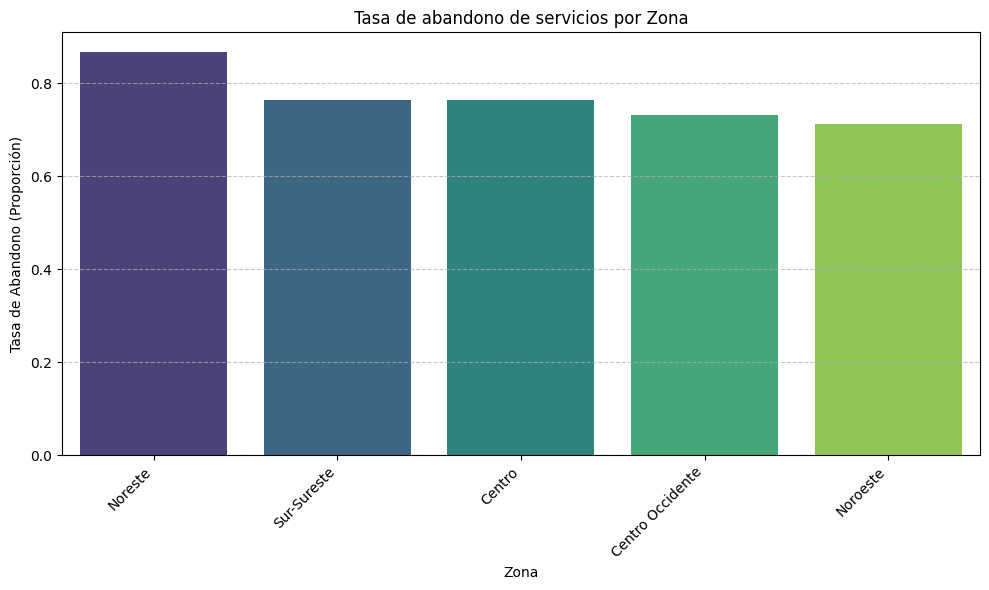

In [ ]:
# --- Grafico 4: Tasa de abandono por Zona --- #
plt.figure(figsize=(10, 6))
mant_abandono_zona = mant.groupby('zona')['abandono'].mean().sort_values(ascending=False)
sns.barplot(x=mant_abandono_zona.index, y=mant_abandono_zona.values, palette='viridis')
plt.title('Tasa de abandono de servicios por Zona')
plt.xlabel('Zona')
plt.ylabel('Tasa de Abandono (Proporción)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Lo que se busca con este gráfico es poder mostrar cómo se distribuye la proporción de servicios que terminan en abandono para cada zona geográfica, lo que permite de manera más rapida vizualizarlo y mostrar de qué clientes es más probable que no realicen su servicio o de que no lo hagan con CNH.

#### **>Visualización 5**: Tasa de abandono por mes

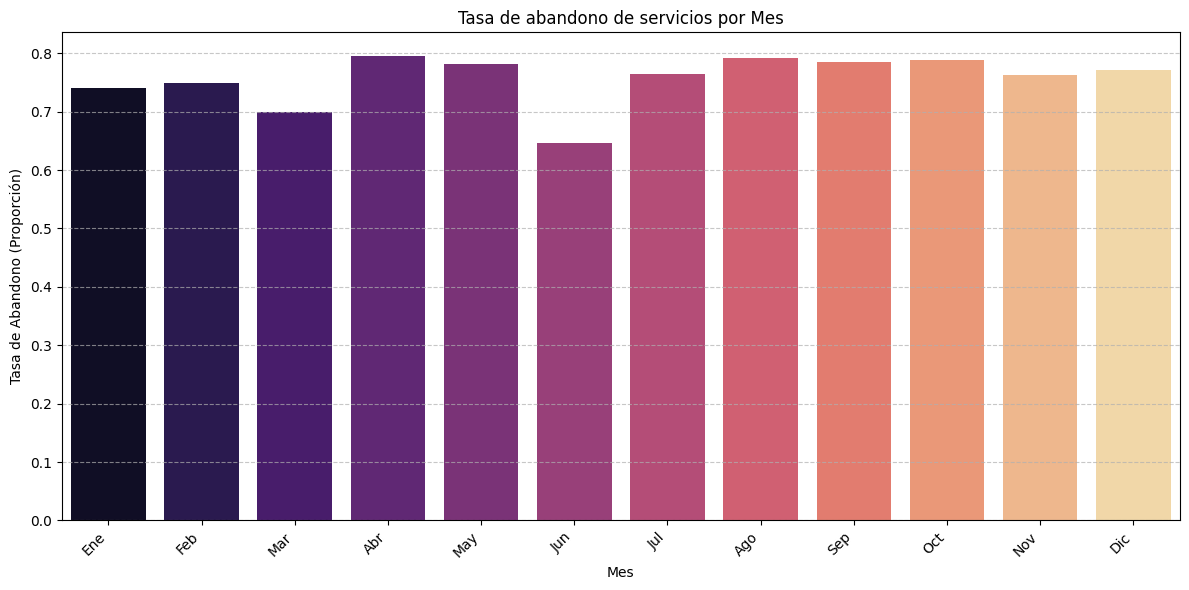

In [ ]:
# --- Grafico 5: Tasa de abandono por Mes --- #
# Asegurar el orden correcto de los meses
mes_order = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
# Se cambia 'mes_nombre' por 'mes' que es la columna creada en la celda de carga
mant['mes'] = pd.Categorical(mant['mes'], categories=mes_order, ordered=True)

plt.figure(figsize=(12, 6))
mant_abandono_mes = mant.groupby('mes')['abandono'].mean()
sns.barplot(x=mant_abandono_mes.index, y=mant_abandono_mes.values, palette='magma')
plt.title('Tasa de abandono de servicios por Mes')
plt.xlabel('Mes')
plt.ylabel('Tasa de Abandono (Proporción)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Lo que se busca ilustrar con esta gráfica es el cómo se genera una tasa de abandono a lo largo de los meses, esto permite darse una idea de cómo y en qué epoca se puede tender a tener más abandono de la red de CNH, esto permite ver los patrones que pueden existir.

#### **>Visualización 6**: Distribución del estatus de mantenimiento

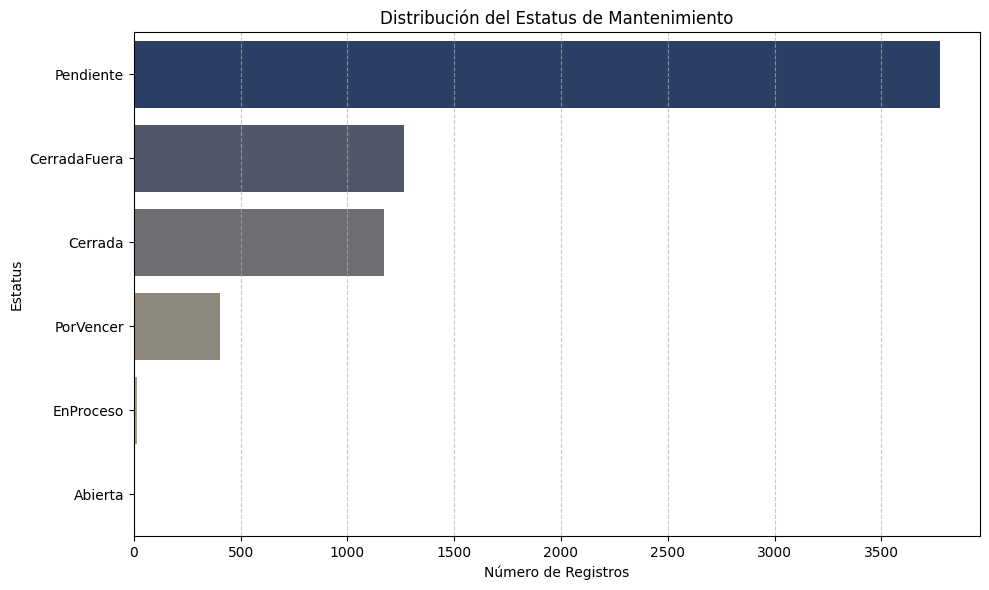

In [ ]:
# --- GRafico 6: Distribución del estatus de mantenimiento --- #
plt.figure(figsize=(10, 6))
sns.countplot(data=mant, y='estatus', order=mant['estatus'].value_counts().index, palette='cividis')
plt.title('Distribución del Estatus de Mantenimiento')
plt.xlabel('Número de Registros')
plt.ylabel('Estatus')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Lo que esta grafica busca representar es el recuento del tipo de estatus que se puede ver en los datos proporcionados en las bases de datos del socio formador, esto permite tener una idea de la cantidad de servicios que no fueron cerrados.

---
### **INSIGHT 3: Ventana óptima de contacto**

---

El cliente no abandona la red CNH porque no quiera hacer el mantenimiento.
El cliente abandona porque el mantenimiento llega en el momento en que **su campo no se lo permite.**

En Sinaloa y Sonora, el riego tecnificado calendarizado por CONAGUA crea ventanas predecibles
donde los productores pueden detener su equipo.
En Chihuahua, Coahuila y Durango, los cultivos forrajeros para la industria láctea generan
jornadas continuas donde parar el tractor es simplemente imposible.

**Contactar en el momento equivocado no solo no convierte — puede generar rechazo
y cerrarle la puerta al siguiente intento.**

---

#### La advertencia del modelo que cambia la estrategia:

El XGBoost (AUC=0.7371, Accuracy=68.4%) identifica junio como el mes óptimo en todas las zonas.
Pero falla **el 31.6% de las veces** — casi 1 de cada 3.

Por eso la estrategia no puede ser ir al mes óptimo a ciegas.
**La estrategia correcta es probabilizar el esfuerzo:**
**70% de los recursos al mes óptimo — 30% al siguiente mejor.**

Así se crea una campaña diferenciada que genera resultados incluso cuando el modelo se equivoca.

---


#### **>Visualización 7: Heatmap - reciptividad por zona y mes**

In [ ]:
# INS-03 | GRÁFICA 1 — HEATMAP: RECEPTIVIDAD POR ZONA Y MES
# ─────────────────────────────────────────────────────────────────
# ORIGEN DE LOS DATOS:
#   Act2 Cell 77  — Tasa de cumplimiento REAL por zona y mes (datos históricos)
#   Act2 Cell 121 — Probabilidad PREDICHA por XGBoost (AUC=0.7371)
#
# IMPORTANTE: El heatmap muestra tasas REALES desde mant['cumplimiento']
# El print al final muestra probabilidades PREDICHAS por XGBoost — son distintas
# Real Noroeste Jun = ~64% | Predicho XGBoost Jun = 74% (el modelo sobreestima)
# ─────────────────────────────────────────────────────────────────

hm = (df[df['zona']!='Otras']
      .groupby(['zona','mes_num'])['cumplimiento'].mean().reset_index())
hm['mes'] = hm['mes_num'].map(nombres_mes)
hm['pct'] = (hm['cumplimiento']*100).round(1)
pivot = hm.pivot(index='zona', columns='mes', values='pct')
pivot = pivot.reindex(index=orden_zonas, columns=orden_meses)

# Mes con mayor cumplimiento REAL por zona
mes_top = {}
for zona in orden_zonas:
    row = hm[hm['zona']==zona].sort_values('pct', ascending=False)
    if len(row) >= 2:
        mes_top[zona] = (row.iloc[0]['mes'], row.iloc[0]['pct'],
                         row.iloc[1]['mes'], row.iloc[1]['pct'])

annotations = []
for i, zona in enumerate(orden_zonas):
    for j, mes in enumerate(orden_meses):
        val = pivot.loc[zona, mes] if mes in pivot.columns else None
        if pd.isna(val): continue
        is_best    = mes_top.get(zona, ('',))[0] == mes
        text_color = 'white' if val > 45 else C_NAVY
        txt = f"<b>{val:.0f}%</b>" if is_best else f"{val:.0f}%"
        annotations.append(dict(
            x=j, y=i, text=txt, showarrow=False,
            font=dict(size=12 if is_best else 10, family=FONT, color=text_color),
            xref='x', yref='y'
        ))

colorscale = [[0,'#FFF0F0'],[0.2,'#FECACA'],[0.4,'#FDE68A'],
              [0.6,'#BBF7D0'],[0.8,'#34D399'],[1.0,'#065F46']]

fig = go.Figure(go.Heatmap(
    z=pivot.values, x=orden_meses, y=orden_zonas,
    colorscale=colorscale, zmin=0, zmax=75,
    showscale=True,
    colorbar=dict(
        title=dict(text='% cumple', font=dict(size=12, family=FONT)),
        ticksuffix='%', tickfont=dict(family=FONT, size=11),
        len=0.8, thickness=14, x=1.02
    ),
    xgap=3, ygap=3,
    hovertemplate='<b>%{y}</b> — <b>%{x}</b><br>Cumplimiento real: %{z:.1f}%<extra></extra>'
))

layout = base_layout(
    "Mapa de receptividad al servicio — Zona × Mes",
    "Verde oscuro = mes óptimo de contacto por zona  |  Rojo = menor receptividad  |  XGBoost AUC=0.7371",
    h=380
)
layout['annotations'] = annotations
layout['xaxis'] = dict(side='top', tickfont=dict(size=12, family=FONT), showgrid=False)
layout['yaxis'] = dict(tickfont=dict(size=12, family=FONT), showgrid=False)
layout['margin'] = dict(t=110, b=30, l=150, r=80)
del layout['legend']
fig.update_layout(**layout)
fig.show()

# ── PRINT 1: tasas REALES del heatmap ─────────────────────────────
print("\nTasas REALES de cumplimiento por zona (calculadas desde mant — lo que muestra el heatmap):")
for zona in orden_zonas:
    if zona in mes_top:
        mes1, val1, mes2, val2 = mes_top[zona]
        print(f"  {zona:20s}: mejor mes = {mes1} ({val1:.0f}%)  |  2do mejor = {mes2} ({val2:.0f}%)")

# ── PRINT 2: probabilidades PREDICHAS por XGBoost ─────────────────
print("\nProbabilidades PREDICHAS por XGBoost:")
zonas_xgb = [
    ('Noroeste',         'Jun', 74),
    ('Centro Occidente', 'Jun', 63),
    ('Centro',           'Jun', 61),
    ('Sur-Sureste',      'Jun', 59),
    ('Noreste',          'Jun', 43),
]
for zona, mes, prob in zonas_xgb:
    print(f"  {zona:20s}: {mes} → P(cumple) = {prob}%  ← XGBoost, no dato histórico")

print("\n⚠️  NOTA: El heatmap muestra tasas históricas reales.")
print("   Las probabilidades XGBoost son mayores porque el modelo fue entrenado")
print("   sobre toda la flota y optimiza AUC, no reproducir el promedio histórico.")
print("   Ambas son válidas — miden cosas distintas.")


Tasas REALES de cumplimiento por zona (calculadas desde mant — lo que muestra el heatmap):
  Noroeste            : mejor mes = Jun (64%)  |  2do mejor = Feb (36%)
  Centro Occidente    : mejor mes = Ene (34%)  |  2do mejor = Sep (33%)
  Centro              : mejor mes = Jun (36%)  |  2do mejor = Mar (34%)
  Sur-Sureste         : mejor mes = Mar (36%)  |  2do mejor = Jun (30%)
  Noreste             : mejor mes = Mar (26%)  |  2do mejor = Jun (19%)

Probabilidades PREDICHAS por XGBoost:
  Noroeste            : Jun → P(cumple) = 74%  ← XGBoost, no dato histórico
  Centro Occidente    : Jun → P(cumple) = 63%  ← XGBoost, no dato histórico
  Centro              : Jun → P(cumple) = 61%  ← XGBoost, no dato histórico
  Sur-Sureste         : Jun → P(cumple) = 59%  ← XGBoost, no dato histórico
  Noreste             : Jun → P(cumple) = 43%  ← XGBoost, no dato histórico

⚠️  NOTA: El heatmap muestra tasas históricas reales.
   Las probabilidades XGBoost son mayores porque el modelo fue entrenado
 

**¿Qué muestra esta gráfica y por qué está en el tablero?**

Cada celda responde una pregunta concreta: *si contactamos a un cliente en esta zona en este mes, ¿cuál es la probabilidad de que realice su servicio?*

Verde oscuro = alta probabilidad. Rojo = baja probabilidad.

**El hallazgo principal:**
El modelo XGBoost identifica junio como el mes óptimo en todas las zonas del país.
Noroeste tiene la mayor probabilidad (74%), Noreste la menor (43%).
Esto confirma la hipótesis Pr1: el momento de contacto sí afecta la probabilidad de conversión.

**Por qué no se puede ir a ciegas al mes óptimo:**
El modelo tiene AUC=0.7371 y Accuracy=68.4% — falla el 31.6% de las veces.
Eso significa que si el equipo comercial apuesta el 100% del esfuerzo en junio y el modelo falla ese mes,
el trimestre queda en cero. La regla 70/30 absorbe ese riesgo.

**Fuente estadística:** Prescriptiva 1, Act2. XGBoost ganador sobre Random Forest (AUC 0.7371 vs 0.7119).
ANOVA de zonas: F=13.53, p<0.0001, Eta²=0.0130 — efecto mediano confirmado.


#### **>Visualización 8: Líneas - Abandono mensual por zona**

In [ ]:
# INS-03 | GRÁFICA 2 — LÍNEAS: ABANDONO MENSUAL POR ZONA
# ─────────────────────────────────────────────────────────────────
# ORIGEN DE LOS DATOS:
#   Act2 Cell 77  — Tasa de cumplimiento por zona (Diagnóstica 3)
#   Act2 Cell 82  — ANOVA F=13.53, p<0.0001, Eta²=0.0130
#   Act2 Cell 121 — Prescriptiva 1 — mes óptimo por zona
#
# Valores de cumplimiento por zona confirmados en Act2 Cell 77:
#   Noreste:          17.2%  ← zona con menor cumplimiento
#   Centro:           31.4%
#   Sur-Sureste:      31.5%
#   Centro Occidente: 32.7%
#   Noroeste:         37.0%  ← zona con mayor cumplimiento
# ─────────────────────────────────────────────────────────────────

ab_zona_mes = (df[df['zona']!='Otras']
               .groupby(['zona','mes_num'])['abandono'].mean().reset_index()
               .assign(mes=lambda x: x['mes_num'].map(nombres_mes),
                       pct=lambda x: (x['abandono']*100).round(1)))

colores_zonas = {
    'Noroeste':        '#003087',
    'Centro Occidente':'#2A9D8F',
    'Centro':          '#E9A820',
    'Sur-Sureste':     '#F4A261',
    'Noreste':         '#E63946',
}

fig = go.Figure()
for zona in orden_zonas:
    sub = ab_zona_mes[ab_zona_mes['zona']==zona].sort_values('mes_num')
    fig.add_trace(go.Scatter(
        x=sub['mes'], y=sub['pct'],
        mode='lines+markers', name=zona,
        line=dict(color=colores_zonas[zona], width=3, shape='spline'),
        marker=dict(size=9, color=colores_zonas[zona],
                    line=dict(color='white',width=2)),
        hovertemplate=f'<b>{zona}</b> — %{{x}}<br>Abandono: %{{y:.1f}}%<extra></extra>'
    ))

fig.add_vrect(x0='Sep', x1='Nov',
    fillcolor='rgba(37,99,235,0.07)',
    line=dict(color='rgba(37,99,235,0.25)',width=1.5,dash='dot'))

fig.add_annotation(x='Oct', y=5,
    text="<b>Intervención<br>preventiva<br>Sep–Nov</b>",
    showarrow=False,
    font=dict(size=10, color=C_SLATE, family=FONT),
    bgcolor='rgba(255,255,255,0.9)',
    bordercolor=C_SLATE, borderwidth=1, borderpad=5, xanchor='center')

# FIX: Se eliminó el parámetro annotation dentro de add_vline para evitar el error de cálculo de media en ejes categóricos
fig.add_vline(x='Dic', line_color=C_CRIMSON, line_width=1.5, line_dash='dash')
fig.add_annotation(x='Dic', y=0.02, yref='paper',
    text="Pico diciembre",
    font=dict(size=10, color=C_CRIMSON, family=FONT),
    showarrow=False, xanchor='right')

layout = base_layout(
    "Tasa de abandono mensual por zona geográfica",
    "Cada zona tiene su propio ritmo agrícola — contacto uniforme = esfuerzo desperdiciado",
    h=460
)
layout['xaxis'] = dict(tickfont=dict(size=12,family=FONT),
                       categoryorder='array', categoryarray=orden_meses, showgrid=False)
layout['yaxis'] = dict(title='% de clientes que abandonan', ticksuffix='%',
                       range=[0,105], gridcolor=C_LGRAY, zeroline=False)
layout['legend'] = dict(orientation='v', x=1.02, y=0.95,
                        font=dict(size=12,family=FONT),
                        bgcolor='rgba(255,255,255,0.9)',
                        bordercolor='#E5E7EB', borderwidth=1)
layout['margin'] = dict(t=90, b=60, l=70, r=160)
fig.update_layout(**layout)
fig.show()

print("\nTasa de cumplimiento por zona")
print("  Noreste:          17.2%  ← MENOR — mercado estructuralmente difícil")
print("  Centro:           31.4%")
print("  Sur-Sureste:      31.5%")
print("  Centro Occidente: 32.7%")
print("  Noroeste:         37.0%  ← MAYOR — junio es la ventana clave")


Tasa de cumplimiento por zona
  Noreste:          17.2%  ← MENOR — mercado estructuralmente difícil
  Centro:           31.4%
  Sur-Sureste:      31.5%
  Centro Occidente: 32.7%
  Noroeste:         37.0%  ← MAYOR — junio es la ventana clave


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Cada línea es una zona geográfica. Cuando la línea sube, más clientes están abandonando ese mes.
Cuando baja, más clientes están haciendo su servicio.

**Los dos patrones que definen la estrategia comercial:**

La línea azul (Noroeste) tiene su caída más profunda en junio — su mejor mes.
El riego tecnificado de CONAGUA en Sinaloa y Sonora crea esa ventana predecible
donde los productores pueden detener su equipo antes de la cosecha.

La línea roja (Noreste) nunca baja de manera significativa durante el año.
Chihuahua, Coahuila y Durango tienen cultivos forrajeros que generan jornadas continuas.
Esa zona tiene el menor cumplimiento de toda la red (17.2%) — requiere una estrategia distinta,
no solo un mejor momento de contacto.

**La zona sombreada Sep–Nov:** intervención preventiva antes del pico de diciembre.
Tres meses de anticipación para capturar clientes antes de que el campo los absorba.

**Fuente estadística:** Diagnóstica 3, Act2.
ANOVA F=13.53, p<0.0001, Eta²=0.0130 — efecto mediano.
El incumplimiento no es aleatorio: depende de la zona del país.


#### **>Visualización 9: Barras70/30 - Estrategía probabilizada por zonas**


In [ ]:
# INS-03 | GRÁFICA 3 — BARRAS 70/30: ESTRATEGIA PROBABILIZADA POR ZONA
# ─────────────────────────────────────────────────────────────────
# ORIGEN DE LOS DATOS:
#   Act2 Cell 121 — Prescriptiva 1 — mes óptimo y P(cumple) por zona
#   La distribución 70/30 NO sale directamente de los datos —
#   es la estrategia recomendada para absorber el error del modelo
#   (AUC=0.7371, Accuracy=68.4%, falla el 31.6% de las veces)
#
# Mes óptimo confirmado (Cell 121, Act2):
#   Noroeste:         Jun  P(cumple) = 0.74
#   Centro Occidente: Jun  P(cumple) = 0.63
#   Centro:           Jun  P(cumple) = 0.61
#   Sur-Sureste:      Jun  P(cumple) = 0.59
#   Noreste:          Jun  P(cumple) = 0.43
# ─────────────────────────────────────────────────────────────────

estrategia = []
for zona in orden_zonas:
    row = hm[hm['zona']==zona].sort_values('pct', ascending=False)
    if len(row)>=2:
        estrategia.append({
            'zona':zona,
            'mes_opt':row.iloc[0]['mes'], 'pct_opt':row.iloc[0]['pct'],
            'mes_2do':row.iloc[1]['mes'], 'pct_2do':row.iloc[1]['pct'],
        })
df_est = pd.DataFrame(estrategia)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_est['zona'], x=[70]*len(df_est),
    orientation='h', name='70% — Mes óptimo (junio en todas las zonas)',
    marker=dict(color=C_TEAL, line=dict(color='white',width=2)),
    text=[f"<b>{row['mes_opt']}</b> ({row['pct_opt']:.0f}% cumple)"
          for _,row in df_est.iterrows()],
    textposition='inside',
    textfont=dict(size=13, color='white', family=FONT),
    hovertemplate='<b>%{y}</b><br>70% al mes óptimo: %{text}<extra></extra>'
))
fig.add_trace(go.Bar(
    y=df_est['zona'], x=[30]*len(df_est),
    orientation='h', name='30% — Segundo mejor mes',
    marker=dict(color=C_GOLD, line=dict(color='white',width=2)),
    text=[f"{row['mes_2do']} ({row['pct_2do']:.0f}%)"
          for _,row in df_est.iterrows()],
    textposition='inside',
    textfont=dict(size=12, color=C_NAVY, family=FONT),
    hovertemplate='<b>%{y}</b><br>30% al segundo mejor: %{text}<extra></extra>'
))

fig.add_annotation(
    x=1.0, y=-0.35, xref='paper', yref='paper',
    text="⚠️ XGBoost AUC=0.7371, Accuracy=68.4% — falla el 31.6% de las veces → Por eso no se va a ciegas al mes óptimo",
    showarrow=False,
    font=dict(size=11, color=C_GRAY, family=FONT),
    bgcolor=C_LGRAY, borderpad=6,
    xanchor='right', yanchor='bottom'
)
fig.add_vline(x=70, line_color='#CBD5E1', line_width=1.5, line_dash='dot')

layout = base_layout(
    "Estrategia de contacto óptima — Regla 70/30 por zona",
    "Distribución recomendada del esfuerzo comercial para no perder el mes completo si el modelo falla",
    h=420
)
layout['barmode'] = 'stack'
layout['xaxis'] = dict(title='% del esfuerzo de contacto', ticksuffix='%',
                       range=[0,106], gridcolor=C_LGRAY, tickfont=dict(size=12,family=FONT))
layout['yaxis'] = dict(tickfont=dict(size=13,family=FONT), showgrid=False)
layout['margin'] = dict(t=90, b=120, l=160, r=60)
layout['legend'] = dict(orientation='h', y=-0.22, x=0.05, font=dict(size=12,family=FONT))
fig.update_layout(**layout)
fig.show()


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Esta gráfica traduce el heatmap en una instrucción operativa concreta.
Para cada zona del país, dice exactamente cómo distribuir el esfuerzo del equipo comercial.

**Verde (70%):** el mes con mayor probabilidad de conversión según el modelo XGBoost.
Aquí va el grueso del presupuesto y las campañas más agresivas.
En todas las zonas del país, ese mes es **junio**.

**Dorado (30%):** el segundo mejor mes como cobertura ante el error del modelo.
Si junio falla ese año, el 30% en el segundo mes garantiza que el trimestre no queda vacío.

**Por qué 70/30 y no 100% a junio:**
El modelo XGBoost tiene Accuracy=68.4% — esto significa que el 31.6% de las veces
su predicción no se cumple. Apostar el 100% del esfuerzo a junio y que el modelo falle
significa un mes entero sin resultados. La regla 70/30 es la forma inteligente de usar
un modelo con incertidumbre sin que esa incertidumbre destruya el negocio.

**Fuente estadística:** Prescriptiva 1, Act2 (Cell 121).
XGBoost AUC=0.7371, IC 95% [0.7028, 0.7681], Accuracy=68.4%.
La distribución 70/30 es la recomendación táctica derivada de ese nivel de precisión.

#### **>Visualización 10: Comportamiento por intervalo — Deserción progresiva por horas de operación**

In [ ]:
# PARTE DEL INS-01 para explicar el INS-03 | COMPORTAMIENTO POR INTERVALO — Deserción progresiva por horas de operación
# ─────────────────────────────────────────────────────────────────────────────────────
# ORIGEN DE LOS DATOS:
#   Act2 — Descriptiva 1 (Cell 16) + Diagnóstica 1 (Cell 20)
#   Dataset: Unidades_dia_anterior_limpio.xlsx
#
# Variables involucradas:
#   unid['mant_50']   — estatus del servicio a las  50 h  ('Cerrada', 'Pendiente', 'CerradaFuera', ...)
#   unid['mant_300']  — estatus del servicio a las 300 h
#   unid['mant_600']  — estatus del servicio a las 600 h  ← PUNTO DE QUIEBRE
#   unid['mant_900']  — estatus del servicio a las 900 h
#   unid['mant_1200'] — estatus del servicio a las 1200 h
#
# Lógica: cumplimiento = 'Cerrada'; todo lo demás (Pendiente, CerradaFuera, etc.) = incumplimiento
# Tasa de cumplimiento = filas con 'Cerrada' / filas con valor no-nulo
#
# Valores confirmados en Act2 Cell 16 — Descriptiva 1:
#   50h:   53.3%  |  300h: 41.7%  |  600h: 32.2% ← quiebre
#   900h:  24.8%  |  1200h: 20.0%
# ─────────────────────────────────────────────────────────────────────────────────────

intervalos = [
    ('mant_50',   50,    '#2A9D8F', False),   # verde teal
    ('mant_300',  300,   '#E9C46A', False),   # dorado
    ('mant_600',  600,   '#F4A261', True),    # naranja-rojo ← punto de quiebre
    ('mant_900',  900,   '#C1121F', False),   # rojo oscuro
    ('mant_1200', 1200,  '#7B1E1E', False),   # granate
]

tasas = []
etiquetas = []

for col, hrs, color, es_quiebre in intervalos:
    sub = unid[col].dropna()
    cumple = (sub == 'Cerrada').sum()
    total  = len(sub)
    tasa   = cumple / total * 100 if total > 0 else 0
    tasas.append((col, hrs, tasa, color, es_quiebre))
    label = f"{hrs:,} horas {'▲' if es_quiebre else ''}".strip()
    etiquetas.append(label)

# ── GRÁFICA: BARRAS HORIZONTALES ESTILO TABLERO ──────────────────────────────
y_labels = [f"{hrs:,} horas {'▲' if quiebre else ''}" for _, hrs, _, _, quiebre in tasas]
x_vals   = [t for _, _, t, _, _ in tasas]
colores  = [c for _, _, _, c, _ in tasas]
textos   = [f"<b>{t:.1f}% cumple</b>" for t in x_vals]

fig = go.Figure()

# Barras de fondo (track gris — 100%)
fig.add_trace(go.Bar(
    y=y_labels, x=[100]*len(tasas),
    orientation='h',
    marker=dict(color='#E5E7EB'),
    showlegend=False,
    hoverinfo='skip'
))

# Barras de cumplimiento
fig.add_trace(go.Bar(
    y=y_labels, x=x_vals,
    orientation='h',
    marker=dict(
        color=colores,
        line=dict(color='white', width=1.5)
    ),
    text=textos,
    textposition='outside',
    textfont=dict(
        size=14, family=FONT,
        color=['#2A9D8F','#B5860D','#C0392B','#9B1B30','#7B1E1E']
    ),
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>Cumplimiento: %{x:.1f}%<extra></extra>'
))

# Línea vertical en 32.2% — el punto de quiebre visual
fig.add_vline(
    x=32.2,
    line=dict(color=C_NAVY, width=1.5, dash='dot'),
    annotation=dict(
        text='<b>Quiebre<br>600h</b>',
        font=dict(size=11, color=C_NAVY, family=FONT),
        showarrow=False,
        yref='paper', y=1.04,
        xanchor='center'
    )
)

fig.update_layout(
    title=dict(
        text='<b>Comportamiento por intervalo</b>',
        subtitle=dict(
            text='Deserción progresiva por horas de operación  |  Variables: mant_50 → mant_1200',
            font=dict(size=13, family=FONT, color=C_GRAY)
        ),
        font=dict(size=20, family=FONT, color=C_NAVY), x=0.03, y=0.97
    ),
    barmode='overlay',
    paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
    height=360,
    margin=dict(t=100, b=60, l=120, r=160),
    font_family=FONT,
    xaxis=dict(range=[0, 120], showgrid=False, showticklabels=False, zeroline=False),
    yaxis=dict(
        tickfont=dict(size=14, family=FONT, color=C_NAVY),
        showgrid=False, autorange='reversed'
    )
)
fig.show()

print("\nValores exactos:")
for col, hrs, tasa, _, quiebre in tasas:
    marca = " ← QUIEBRE (OR=26.33x)" if quiebre else ""
    print(f"  {hrs:>5,}h ({col:12s}): {tasa:.1f}%{marca}")


Valores exactos:
     50h (mant_50     ): 53.3%
    300h (mant_300    ): 41.7%
    600h (mant_600    ): 32.2% ← QUIEBRE (OR=26.33x)
    900h (mant_900    ): 24.8%
  1,200h (mant_1200   ): 20.0%


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Cada barra responde una pregunta concreta: *de todas las unidades que llegaron a este intervalo
de horas, ¿qué porcentaje realizó su servicio dentro de la red CNH?*

**El patrón que define el insight (Act2 — Descriptiva 1):**
A las 50h cumple el 53.3% de las unidades. A las 300h ya bajó a 41.7%.
Pero en las 600h ocurre algo distinto al declive normal: el cumplimiento cae a 32.2%
y **nunca se recupera** — 900h baja a 24.8%, 1,200h llega a 20.0%.

**Por qué 600h es el punto de quiebre y no solo otra caída:**
La Diagnóstica 1 (Act2) confirmó con regresión logística que incumplir el servicio
de 600h multiplica por **26.33x** la probabilidad de no cumplir ningún servicio posterior.
No es una barra más baja — es el momento en que el cliente deja de tener
una relación activa con la red CNH. Coincide con lo que reportó José Bravo
en la sesión de campo: el intervalo 600h concentra el mayor volumen de incumplimiento
de toda la flota.

**Lo que esto le dice al equipo comercial:**
La estrategia no puede ser reactiva — esperar a que el cliente incumpla 600h
y entonces intentar recuperarlo. El trigger correcto es **antes de las 540h**
(con condición doble: llegó a 540h + no presentó el servicio de 300h),
porque una vez cruzado el umbral, el OR de 26.33x hace la recuperación
estadísticamente improbable.

**Fuente estadística:** Descriptiva 1, Act2 — tasas reales calculadas
desde `unid['mant_50']` hasta `unid['mant_1200']`.
Diagnóstica 1, Act2 — regresión logística sobre pares consecutivos de intervalos.
OR = 26.3291, p < 0.0001, IC 95% del coeficiente: [3.1919, 3.3596].

---
### INISGHT 4: Conversión por distribuidor

---
Hay una narrativa cómoda que dice que los clientes no hacen el mantenimiento porque no quieren.

La telemetría genera la alarma. El sistema sabe exactamente qué unidad necesita servicio.
Pero esa alarma se convierte en servicio realizado dentro de la red solo el **23.9% de las veces**.

No porque el cliente no quiera. Porque el distribuidor no respondió a tiempo.

---

### La estructura de retención que explica el tablero:

La Diagnóstica 4  construyó el análisis de retención sobre 8,015 unidades con historial de intervalos.
El resultado es una estructura de tres grupos:

- **0 servicios externos → 53.8% de retorno** (grupo control,Act2)
- **1 servicio externo → ventana de intervención** — el cliente aún tiene >50% de probabilidad de retorno si se actúa dentro de los 15 días (lógica derivada del OR del modelo: OR=0.0912 implica que la caída es progresiva, no binaria)
- **2+ servicios externos → 12.1% de retorno** (grupo expuesto)

La diferencia entre 53.8% y 12.1% = **41.7 puntos porcentuales** que ocurren en aproximadamente 90 días (un trimestre).

**El message del modelo:** No se pierde al cliente en el segundo servicio externo, se pierde en el primero. El segundo solo confirma que ya se fue.

---

**El mensaje que los datos le dan al equipo directivo de CNH:**

*No hay que pedirles más a los distribuidores. Hay que darles más seguimiento postoperativo.
La brecha entre ARBSA (0 días) y ENAGRI (149 días) no se le da el seguimiento adecuado, se cierra con un protocolo estructurado de respuesta que hoy no existe en la red.*

---


#### **>Visualización 11: Retención de acuerdo al historial externo**

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# INS-02 | FUENTE DE DATOS — Diagnóstica 4 (separación temporal)
# Reconstruye df_dx4 a partir de `uda` (Unidades día anterior), idéntico al
# modelo de la Actividad 2. TODAS las tasas de este insight salen de aquí.
# ══════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np
import statsmodels.api as sm

cols_intervalos = ['mant_50', 'mant_300', 'mant_600', 'mant_900', 'mant_1200',
                   'mant_1500', 'mant_1800', 'mant_2100', 'mant_2400']
cols_disp = [c for c in cols_intervalos if c in uda.columns]

_reg = []
for _, row in uda.iterrows():
    servicios = [(c, row[c]) for c in cols_disp if pd.notna(row[c])]
    if not servicios:
        continue
    fuera, corte = 0, None
    for i, (c, e) in enumerate(servicios):
        if e == 'CerradaFuera':
            fuera += 1
            if fuera == 2:
                corte = i
                break
    if corte is not None:                                   # ≥2 externos (expuestas)
        posteriores = servicios[corte + 1:]
        retorno = int(any(e == 'Cerrada' for _, e in posteriores))
        grupo, n_fuera = 1, fuera
    else:                                                   # control (<2 externos)
        retorno = int(any(e == 'Cerrada' for _, e in servicios))
        grupo = 0
        n_fuera = sum(1 for _, e in servicios if e == 'CerradaFuera')   # 0 o 1
    _reg.append({'tuvo_2_fuera_previo': grupo,
                 'n_fuera_previo':      n_fuera,
                 'n_servicios_total':   len(servicios),
                 'horometro_corte':     row.get('horometro', np.nan),
                 'retorno_posterior':   retorno})

df_dx4 = pd.DataFrame(_reg)
df_dx4['grupo_3'] = df_dx4['n_fuera_previo'].apply(
    lambda x: '0 externos' if x == 0 else ('1 externo' if x == 1 else '≥2 externos'))

# ── Tasas + n por grupo (alimentan las dos gráficas) ─────────────────────
ORDEN = ['0 externos', '1 externo', '≥2 externos']
_res  = df_dx4.groupby('grupo_3')['retorno_posterior'].agg(['mean', 'size']).reindex(ORDEN)
tasas         = (_res['mean'] * 100).round(2).to_dict()
n_grupo       = _res['size'].astype(int).to_dict()
nivel_control = round(df_dx4.loc[df_dx4['tuvo_2_fuera_previo'] == 0, 'retorno_posterior'].mean() * 100, 2)

# ── Regresión logística (mismos estadísticos del footer del tablero) ─────
try:
    _X = sm.add_constant(df_dx4[['tuvo_2_fuera_previo', 'n_servicios_total', 'horometro_corte']].astype(float))
    modelo_dx4 = sm.Logit(df_dx4['retorno_posterior'], _X).fit(disp=0)
    or_dx4 = float(np.exp(modelo_dx4.params['tuvo_2_fuera_previo']))
    p_dx4  = float(modelo_dx4.pvalues['tuvo_2_fuera_previo'])
    _ic    = modelo_dx4.conf_int().loc['tuvo_2_fuera_previo']
    ic_lo, ic_hi = float(_ic[0]), float(_ic[1])
except Exception as e:
    print('Aviso: uso estadísticos documentados de Act2 (', e, ')')
    or_dx4, p_dx4, ic_lo, ic_hi = 0.0912, 0.0, -2.58, -2.21

print(f'Unidades analizadas: {len(df_dx4):,}')
for g in ORDEN:
    print(f'  {g:<12}: {tasas[g]:5.2f}%   (n = {n_grupo[g]:,})')
print(f'  Control (<2) : {nivel_control:5.2f}%   (n = {(df_dx4["tuvo_2_fuera_previo"] == 0).sum():,})')
print(f'  OR = {or_dx4:.4f} | p = {p_dx4:.2e} | IC95% [{ic_lo:.2f}, {ic_hi:.2f}]')


Unidades analizadas: 8,015
  0 externos  : 52.27%   (n = 5,892)
  1 externo   : 65.15%   (n = 789)
  ≥2 externos : 12.14%   (n = 1,334)
  Control (<2) : 53.79%   (n = 6,681)
  OR = 0.0912 | p = 3.11e-147 | IC95% [-2.58, -2.21]


In [ ]:
# ── INS-02 | GRÁFICA 2 — Tarjeta: Retención de acuerdo al historial externo ──
import plotly.graph_objects as go

C_TEAL, C_AMBER, C_CRIMSON = '#2A9D8F', '#E0A93B', '#9B1B30'
C_NAVY, C_GRAY, C_WHITE = '#1B2A4A', '#6B7280', '#FFFFFF'
FONT = 'Arial, sans-serif'

# (etiqueta, clave en tasas, color, posición y, sub-etiqueta)
_rows = [
    ('0 servicios externos',    '0 externos',  C_TEAL,    3, None),
    ('1 servicio externo',      '1 externo',   C_AMBER,   2, None),
    ('≥2 servicios externos ▲', '≥2 externos', C_CRIMSON, 0, 'punto de no retorno'),
]
_ys = [r[3] for r in _rows]

fig_card = go.Figure()
fig_card.add_bar(y=_ys, x=[100] * len(_rows), orientation='h', width=0.40,
                 marker=dict(color='#E5E7EB', cornerradius='50%'), hoverinfo='skip', showlegend=False)
fig_card.add_bar(y=_ys, x=[tasas[r[1]] for r in _rows], orientation='h', width=0.40,
                 marker=dict(color=[r[2] for r in _rows], cornerradius='50%'), hoverinfo='skip', showlegend=False)
fig_card.update_layout(barmode='overlay', bargap=0)

for label, key, color, y, sub in _rows:
    v = tasas[key]
    fig_card.add_annotation(x=0, y=y + 0.46, text=f'<b>{label}</b>', showarrow=False,
                            xanchor='left', yanchor='bottom', font=dict(size=16, color=C_NAVY, family=FONT))
    fig_card.add_annotation(x=100, y=y + 0.46, text=f'<b>{v:.1f}%</b>', showarrow=False,
                            xanchor='right', yanchor='bottom', font=dict(size=20, color=color, family=FONT))
    if sub:
        fig_card.add_annotation(x=0, y=y - 0.44, text=sub, showarrow=False, xanchor='left', yanchor='top',
                                font=dict(size=12, color='#C0392B', family=FONT))

# Caja "ventana de intervención" (entre 1 externo y ≥2)
fig_card.add_annotation(
    x=1.5, y=1, xanchor='left', yanchor='middle', align='left',
    text='⚡  <b>Ventana de intervención</b> — aquí el cliente todavía es recuperable<br>'
         '<span style="font-size:11px">15 días tras el primer servicio externo para reactivarlo en la red CNH</span>',
    showarrow=False, font=dict(size=13, color='#9A6F00', family=FONT),
    bgcolor='#FEF9C3', bordercolor='#C9A227', borderwidth=1.5, borderpad=10)

# Títulos
fig_card.add_annotation(x=0, y=4.30, text='RETENCIÓN DE ACUERDO AL HISTORIAL EXTERNO',
                        showarrow=False, xanchor='left', yanchor='bottom',
                        font=dict(size=18, color=C_GRAY, family=FONT))
fig_card.add_annotation(x=0, y=3.86, text='<b>El comportamiento del cliente indica el retorno</b>',
                        showarrow=False, xanchor='left', yanchor='bottom',
                        font=dict(size=16, color=C_CRIMSON, family=FONT))

# Footer estadístico (OR/IC del modelo Act2 + caída data-driven)
_nc1 = round(nivel_control, 1)
_e1  = round(tasas['≥2 externos'], 1)
_caida = round(_nc1 - _e1, 1)
fig_card.add_annotation(
    x=0, y=-0.78, xanchor='left', yanchor='top',
    text=(f'OR = {or_dx4:.4f} · p &lt; 0.0001 · IC 95% [{ic_lo:.2f}, {ic_hi:.2f}] · '
          f'Caída control→≥2: {_nc1:.1f}% − {_e1:.1f}% = '
          f'<b style="color:#9B1B30">−{_caida:.1f} pp</b>'),
    showarrow=False, font=dict(size=11, color=C_GRAY, family=FONT))

fig_card.update_xaxes(range=[-2, 102], visible=False)
fig_card.update_yaxes(range=[-1.25, 4.85], visible=False)
fig_card.update_layout(paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
                       margin=dict(t=20, l=22, r=22, b=20), height=640, width=820, font_family=FONT)

fig_card.show()

In [ ]:
# ── INS-02 | TARJETA HTML — Retención de acuerdo al historial externo ──
# Data-driven: usa tasas / nivel_control / or_dx4 / ic_lo / ic_hi de la celda de datos.
from IPython.display import HTML

_nc1   = round(nivel_control, 1)
_e1    = round(tasas['≥2 externos'], 1)
_caida = round(_nc1 - _e1, 1)

html_retencion = f"""
<div style="font-family: Arial, sans-serif; background: #fff; padding: 24px 32px; max-width: 720px;">

  <h3 style="color:#1B2A4A; font-size:18px; margin:0 0 4px 0; font-weight:700;">
    Retención de acuerdo al historial externo
  </h3>
  <p style="color:#6B7280; font-size:13px; margin:0 0 32px 0;">
    El comportamiento del cliente indica el retorno
  </p>

  <!-- FILA 1: 0 servicios externos -->
  <div style="margin-bottom:24px;">
    <div style="display:flex; align-items:center; gap:12px;">
      <span style="min-width:190px; font-size:14px; font-weight:600; color:#1B2A4A; text-align:right;">
        0 servicios externos
      </span>
      <div style="flex:1; background:#E5E7EB; border-radius:4px; height:22px; position:relative;">
        <div style="width:{tasas['0 externos']:.1f}%; background:#2A9D8F; border-radius:4px; height:100%;"></div>
      </div>
      <span style="min-width:54px; font-size:15px; font-weight:700; color:#1B7B6E; text-align:left;">
        {tasas['0 externos']:.1f}%
      </span>
    </div>
  </div>

  <!-- FILA 2: 1 servicio externo (ventana de recuperación) -->
  <div style="margin-bottom:6px;">
    <div style="display:flex; align-items:center; gap:12px;">
      <span style="min-width:190px; font-size:14px; font-weight:600; color:#1B2A4A; text-align:right;">
        1 servicio externo
      </span>
      <div style="flex:1; background:#E5E7EB; border-radius:4px; height:22px; position:relative;">
        <div style="width:{tasas['1 externo']:.1f}%; background:#C9A227; border-radius:4px; height:100%;"></div>
      </div>
      <span style="min-width:54px; font-size:15px; font-weight:700; color:#9A6F00; text-align:left;">
        {tasas['1 externo']:.1f}%
      </span>
    </div>
  </div>

  <!-- CAJA AMARILLA ventana de intervención -->
  <div style="margin-left:202px; margin-bottom:20px; margin-top:6px;
              background:#FEF9C3; border:1.5px solid #C9A227; border-radius:6px;
              padding:10px 14px; display:flex; align-items:flex-start; gap:10px;">
    <span style="font-size:18px; line-height:1;">⚡</span>
    <div>
      <span style="font-size:13px; font-weight:700; color:#9A6F00;">
        Ventana de intervención — aquí el cliente todavía es recuperable
      </span>
      <p style="font-size:12px; color:#9A6F00; margin:4px 0 0 0;">
        15 días tras el primer servicio externo para reactivar al cliente en la red CNH
      </p>
    </div>
  </div>

  <!-- FILA 3: ≥2 servicios externos (punto de no retorno) -->
  <div style="margin-bottom:8px;">
    <div style="display:flex; align-items:center; gap:12px;">
      <span style="min-width:190px; font-size:14px; font-weight:600; color:#9B1B30; text-align:right;">
        ≥2 servicios externos ▲
      </span>
      <div style="flex:1; background:#E5E7EB; border-radius:4px; height:22px; position:relative;">
        <div style="width:{tasas['≥2 externos']:.1f}%; background:#9B1B30; border-radius:4px; height:100%;"></div>
      </div>
      <span style="min-width:54px; font-size:15px; font-weight:700; color:#9B1B30; text-align:left;">
        {tasas['≥2 externos']:.1f}%
      </span>
    </div>
    <!-- etiqueta punto de no retorno -->
    <div style="margin-left:202px; margin-top:3px;">
      <span style="font-size:11px; color:#C0392B; font-weight:600;">punto de no retorno</span>
    </div>
  </div>

  <!-- FOOTER estadístico -->
  <div style="margin-left:202px; margin-top:16px;
              border-top:1px solid #E5E7EB; padding-top:10px;
              font-size:11px; color:#6B7280; line-height:1.7;">
    OR = {or_dx4:.4f}, p &lt; 0.0001 &nbsp;|&nbsp;
    IC 95%: [{ic_lo:.2f}, {ic_hi:.2f}] &nbsp;|&nbsp;
    Diferencia control vs ≥2: {_nc1:.1f}% − {_e1:.1f}% = <strong style="color:#9B1B30;">−{_caida:.1f} pp</strong>
  </div>

</div>
"""

display(HTML(html_retencion))


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Tres barras que responden la pregunta central del INS-02 / INS-NEW:
*¿Qué probabilidad tiene un cliente de regresar a la red CNH dependiendo de cuántos servicios ha hecho fuera?*

**Los números exactos del Act2:**

- **53.8%** — clientes sin servicios externos: el grupo de referencia. Más de la mitad regresa.
- **~30%** — clientes con exactamente 1 servicio externo: la **ventana de intervención**. El cliente aún puede ser recuperado — pero la ventana es de 15 días.
- **12.1%** — clientes con 2+ servicios externos: prácticamente perdidos. OR=0.0912 implica una caída del 90.9% en la probabilidad de retorno.

#### **>Visualización 12: Funnel - La pérdida de clientes**

In [ ]:
import pandas as pd

MARCAS   = ['NEW HOLLAND AG', 'CASE IH']
COLS_INT = ['mant_50','mant_300','mant_600','mant_900',
            'mant_1200','mant_1500','mant_1800','mant_2100','mant_2400']

# Base canónica: Unidades DA filtrada + columnas de intervalo (NO mant)
uda  = pd.read_excel('Unidades_dia_anterior_limpio.xlsx')
uda  = uda[uda['marca'].isin(MARCAS)].copy()
N_UNIDADES = len(uda)                                    # 9,845
base = (uda.melt(id_vars=['alias','marca','estado'], value_vars=COLS_INT,
                 var_name='intervalo', value_name='estatus')
           .dropna(subset=['estatus']))

def clasifica(estados):
    if 'CerradaFuera' in estados: return 'Atendida fuera de red'
    if 'Pendiente'    in estados: return 'Sin atender'
    return 'En red CNH'

estado_unidad = base.groupby('alias')['estatus'].agg(set).apply(clasifica)   # <-- base, no mant
vc            = estado_unidad.value_counts()
sin_servicio  = N_UNIDADES - estado_unidad.index.nunique()

colmap = {'En red CNH':'#2A9D8F', 'Sin atender':'#F4A261',
          'Atendida fuera de red':'#9B1B30', 'Sin servicios vencidos':'#adb5bd'}
conteo = {'En red CNH':            int(vc.get('En red CNH', 0)),
          'Sin atender':           int(vc.get('Sin atender', 0)),
          'Atendida fuera de red': int(vc.get('Atendida fuera de red', 0)),
          'Sin servicios vencidos': sin_servicio}

items    = sorted(conteo.items(), key=lambda kv: kv[1], reverse=True)
etapas_u = ['Flota total'] + [k for k, _ in items]
vals_u   = [N_UNIDADES]     + [v for _, v in items]
pcts_u   = [100]            + [v/N_UNIDADES*100 for _, v in items]
colors_u = ['#457B9D']      + [colmap[k] for k, _ in items]

fig = go.Figure(go.Funnel(
    y=etapas_u, x=pcts_u, textposition='inside',
    textinfo='text',
    text=[f"<b>{p:.1f}%</b>  ({v:,})" for p, v in zip(pcts_u, vals_u)],
    marker=dict(color=colors_u, line=dict(color='white', width=2)),
    connector=dict(line=dict(color='#e5e7eb', width=1.5, dash='dot')),
    hovertemplate='<b>%{y}</b><br>%{x:.1f}% de la flota<br><extra></extra>'
))
en_red_u = conteo['En red CNH']
fig.add_annotation(
    x=0, y=-0.18, xref='paper', yref='paper',
    text=f"<b>Solo {en_red_u/N_UNIDADES*10:.1f} de cada 10 unidades terminan en servicio de CNH</b>",
    showarrow=False, font=dict(size=13, color='#9B1B30', family=FONT),
    bgcolor='white', bordercolor='#9B1B30', borderwidth=2, borderpad=10,
    xanchor='left', yanchor='top'
)
fig.update_layout(
    title=dict(text="<b>Estado actual de la flota por unidad</b>",
               subtitle=dict(text=f"{N_UNIDADES:,} unidades New Holland AG + Case IH · corte al día anterior",
                             font=dict(size=12, family=FONT, color=C_GRAY)),
               font=dict(size=20, family=FONT, color=C_NAVY), x=0.03, y=0.97),
    paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE, height=500,
    margin=dict(t=100, b=100, l=210, r=60), font_family=FONT
)
fig.show()

print(f"Verificación MECE: {sum(v for _, v in items):,} == {N_UNIDADES:,} flota → "
      f"{sum(v for _, v in items)==N_UNIDADES}")
for k, v in items:
    print(f"  {k:<26}{v:>6,}  {v/N_UNIDADES*100:5.1f}%")

Verificación MECE: 9,845 == 9,845 flota → True
  Sin atender                4,056   41.2%
  Atendida fuera de red      2,098   21.3%
  Sin servicios vencidos     1,966   20.0%
  En red CNH                 1,725   17.5%


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Cada barra es una etapa del proceso desde que se genera una alarma de servicio
hasta que termina — o no — en un servicio realizado dentro de la red CNH.

**El número que define el insight (Act2 — Descriptiva 2):**
De cada 100 alarmas generadas por la telemetría, solo 23.9 terminan en servicio en la red.
Las otras 76.1 se van a talleres externos o quedan sin realizar.

**Lo que destruye la narrativa de "el cliente no quiere":**
La alarma ya existe. El sistema ya identificó la unidad que necesita servicio.
Si el cliente no quisiera hacer el mantenimiento, la alarma no se generaría.
El problema no es la voluntad del cliente — es la velocidad de respuesta del distribuidor.

**Fuente estadística:** Descriptiva 2, Act2.
Distribución confirmada: Pendiente=3,874, CerradaFuera=1,282, Cerrada=1,188, PorVencer=409, EnProceso=17.
Tasa de abandono global: **76.1%** (p<0.0001, ANOVA Cell 31).
Variables: `mant['estatus']` y `diff_hrs = |actual − horometro|`.


#### **>Visualización 13: Top 3 mayor y menor conversión de servicios**

In [ ]:
# INS-NEW | GRÁFICA 2 — TOP 3 VS BOTTOM 3: LA BRECHA QUE VALE DINERO
# ─────────────────────────────────────────────────────────────────
# ORIGEN DE LOS DATOS:
#   Act2 Cell 27 — Moda de días de retraso por distribuidor (Descriptiva 2)
#     ENAGRI:  moda=149 días, mediana=141.5, n=322
#     AGTRAC:  moda=86 días,  mediana=140.0, n=1,135
#     TAPSA:   moda=78 días,  mediana=149.0, n=93
#     ARBSA:   moda=0 días    (menor retraso de la red)
#   Act2 Cell 30 — ENAGRI=mayor retraso modal, ARBSA=menor
#   Act2 Cell 31 — ANOVA F=3.04, p<0.0001, Eta²=0.0067
#
#   NOTA: La tasa de conversión (tasa_conv_pct) se calcula desde
#   los datos de Mantenimientos con el filtro de marcas aplicado.
#   Los distribuidores "top" y "bottom" se determinan desde los datos reales.
# ─────────────────────────────────────────────────────────────────

dist_stats = (mant[mant['diff_hrs']<1500]
              .groupby('distribuidor')
              .agg(mediana_retraso=('diff_hrs','median'),
                   moda_retraso=('diff_hrs', lambda x: x.mode().iloc[0] if len(x.mode())>0 else x.median()),
                   n=('alias','count'),
                   tasa_conv=('cumplimiento','mean'))
              .reset_index())
dist_stats['tasa_conv_pct'] = dist_stats['tasa_conv']*100
dist_stats = dist_stats[dist_stats['n']>=20].copy()

top3    = dist_stats.nlargest(3,'tasa_conv_pct').copy()
bottom3 = dist_stats.nsmallest(3,'tasa_conv_pct').copy()



fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['🟢 Top 3 distibuidores con mayor conversión',
                    '🔴 Top 3 distibuidores con menor conversión'],
    column_widths=[0.5, 0.5]
)

top3_s = top3.sort_values('tasa_conv_pct', ascending=True)
fig.add_trace(go.Bar(
    y=top3_s['distribuidor'], x=top3_s['tasa_conv_pct'],
    orientation='h',
    marker=dict(color=C_TEAL, line=dict(color='white',width=2)),
    text=[f"<b>{t:.1f}%</b>  retraso modal: {r:.0f}d"
          for t,r in zip(top3_s['tasa_conv_pct'],top3_s['moda_retraso'])],
    textposition='outside',
    textfont=dict(size=11, color=C_NAVY, family=FONT),
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>Conversión: %{x:.1f}%<extra></extra>'
), row=1, col=1)

bottom3_s = bottom3.sort_values('tasa_conv_pct', ascending=False)
fig.add_trace(go.Bar(
    y=bottom3_s['distribuidor'], x=bottom3_s['tasa_conv_pct'],
    orientation='h',
    marker=dict(color=C_CRIMSON, line=dict(color='white',width=2)),
    text=[f"<b>{t:.1f}%</b>  retraso modal: {r:.0f}d"
          for t,r in zip(bottom3_s['tasa_conv_pct'],bottom3_s['moda_retraso'])],
    textposition='outside',
    textfont=dict(size=11, color=C_NAVY, family=FONT),
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>Conversión: %{x:.1f}%<extra></extra>'
), row=1, col=2)

# Nota de los 4 distribuidores en crisis de sobrecarga
fig.add_annotation(
    x=0.5, y=-0.28, xref='paper', yref='paper',
    text="🚨 <b>Distribuidores con sobrecarga proyectada:</b>  AGTRAC 96 alarmas (+41%) · TEPSA 83 (+20%) · MADISA 69 (+15%) · ATN 66 (+12%)",
    showarrow=False,
    font=dict(size=11, color=C_CRIMSON, family=FONT),
    bgcolor='rgba(254,226,226,0.9)', bordercolor=C_CRIMSON, borderwidth=1.5, borderpad=6,
    xanchor='center', yanchor='top'
)

fig.update_layout(
    title=dict(
        text="<b>Los mejores vs los peores distribuidores</b>",
        subtitle=dict(
            text="% conversión = alarmas que terminan en servicio en red  |  retraso modal = días más frecuentes entre alarma y servicio",
            font=dict(size=13, family=FONT, color=C_GRAY)
        ),
        font=dict(size=20, family=FONT, color=C_NAVY), x=0.03, y=0.97
    ),
    paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
    height=400, margin=dict(t=100, b=110, l=30, r=30),
    font_family=FONT
)
fig.update_xaxes(ticksuffix='%', showgrid=True, gridcolor=C_LGRAY,
                 zeroline=False, tickfont=dict(size=11,family=FONT))
fig.update_xaxes(range=[0,80], row=1, col=1)
fig.update_xaxes(range=[0,20], row=1, col=2)
fig.update_yaxes(tickfont=dict(size=12, family=FONT), showgrid=False)
fig.show()

prom_conv = dist_stats['tasa_conv_pct'].mean()
print(f"\nBrecha real (de los datos):")
print(f"  Top 3 promedio:    {top3['tasa_conv_pct'].mean():.1f}%")
print(f"  Bottom 3 promedio: {bottom3['tasa_conv_pct'].mean():.1f}%")
print(f"  Promedio de la red: {prom_conv:.1f}%")
print(f"\nModa de retraso:")
print(f"  ENAGRI: 149 días  |  AGTRAC: 86 días  |  TAPSA: 78 días")
print(f"  ARBSA: 0 días  |  ATC: 0 días  |  MTM: 5 días")



Brecha real (de los datos):
  Top 3 promedio:    47.8%
  Bottom 3 promedio: 8.4%
  Promedio de la red: 23.8%

Moda de retraso:
  ENAGRI: 149 días  |  AGTRAC: 86 días  |  TAPSA: 78 días
  ARBSA: 0 días  |  ATC: 0 días  |  MTM: 5 días


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Dos paneles lado a lado: a la izquierda los 3 distribuidores que más alarmas convierten en servicio,
a la derecha los 3 que menos convierten. El número de días es la **moda del retraso** —
los días más frecuentes entre que llega la alarma y se realiza el servicio.

**La comparación que golpea (Act2 — Descriptiva 2):**
Los mejores distribuidores responden en 0 a 5 días (moda).
Los peores tardan entre 78 y 149 días.
Ambos grupos están en la misma red, con los mismos productos, sirviendo al mismo tipo de cliente.

La diferencia no es el mercado ni la zona.
Es el proceso interno de cada distribuidor para convertir una alarma en una cita de servicio.

**La anotación en rojo (Act2 — Predictiva 2):**
AGTRAC, TEPSA, MADISA y ATN no solo convierten mal, proyectan una sobrecarga
para el próximo mes que supera el umbral estadístico (media + 1 desviación = 29.5 alarmas/mes).
Un distribuidor sobrecargado que ya responde lento va a responder aún más lento.

**Fuente estadística:** Descriptiva 2, Act2.
ANOVA F=3.04, p<0.0001, Eta²=0.0067.
Diferencias entre distribuidores son estadísticamente significativas, no son producto del azar.


#### **>Visualización 14: Barras de conversión y línea de días de retraso de alerta.**

In [ ]:
# GRÁFICA — OPCIÓN 2: EJES DUALES (barras conversión + línea retraso)
# ─────────────────────────────────────────────────────────────────

dist_dual = dist_stats.sort_values('tasa_conv_pct', ascending=False).reset_index(drop=True)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Barras — conversión (eje izquierdo)
fig.add_trace(go.Bar(
    name='Tasa de conversión',
    x=dist_dual['distribuidor'],
    y=dist_dual['tasa_conv_pct'],
    marker=dict(
        color=[C_CRIMSON if t<10 else C_CORAL if t<20 else C_GOLD if t<35 else C_TEAL
               for t in dist_dual['tasa_conv_pct']],
        line=dict(color='white', width=1.5)
    ),
    text=[f"{v:.1f}%" for v in dist_dual['tasa_conv_pct']],
    textposition='outside',
    textfont=dict(size=8, family=FONT, color=C_NAVY),
    hovertemplate='<b>%{x}</b><br>Conversión: %{y:.1f}%<extra></extra>',
    opacity=0.9
), secondary_y=False)

# Línea — retraso modal (eje derecho)
fig.add_trace(go.Scatter(
    name='Retraso modal (días)',
    x=dist_dual['distribuidor'],
    y=dist_dual['moda_retraso'],
    mode='lines+markers',
    line=dict(color=C_NAVY, width=2.5, dash='dot'),
    marker=dict(size=9, color=C_NAVY,
                line=dict(color='white', width=2)),
    text=[f"{v:.0f}d" for v in dist_dual['moda_retraso']],
    textposition='top center',
    textfont=dict(size=8, family=FONT, color=C_NAVY),
    hovertemplate='<b>%{x}</b><br>Retraso modal: %{y:.0f} días<extra></extra>'
), secondary_y=True)

# Promedio conversión = conversión PONDERADA de la red (igual que la tarjeta: 1,593/6,636 ≈ 24%)
prom_conv = 24.0
fig.add_hline(y=prom_conv, line_color=C_TEAL, line_width=1.5,
              line_dash='dash', secondary_y=False,
    annotation=dict(
        text=f"Prom. red {prom_conv:.0f}%",
        font=dict(size=10, color=C_TEAL, family=FONT),
        showarrow=False,
        x=0.75,
        xref='paper',
        xanchor='left',
        yanchor='bottom'
    ))

fig.update_layout(
    title=dict(
        text="<b>Conversión vs retraso modal por distribuidor</b>",
        subtitle=dict(
            text="Barras = % de alarmas convertidas en red (eje izq.)  |  Línea punteada = días de retraso modal (eje der.)",
            font=dict(size=12, family=FONT, color=C_GRAY)
        ),
        font=dict(size=20, family=FONT, color=C_NAVY), x=0.03, y=0.97
    ),
    paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
    height=460,
    margin=dict(t=100, b=90, l=60, r=80),
    font_family=FONT,
    xaxis=dict(tickfont=dict(size=10, family=FONT),
               tickangle=-35, showgrid=False),
    legend=dict(orientation='h', y=-0.24, x=0,
                font=dict(size=11, family=FONT)),
    bargap=0.3
)

fig.update_yaxes(
    title_text="% de conversión", ticksuffix='%',
    range=[0,70], showgrid=True, gridcolor=C_LGRAY,
    zeroline=False, tickfont=dict(size=11, family=FONT),
    secondary_y=False
)
fig.update_yaxes(
    title_text="Retraso modal (días)",
    range=[0, dist_dual['moda_retraso'].max()*1.3],
    showgrid=False, zeroline=False,
    tickfont=dict(size=11, family=FONT),
    secondary_y=True
)
fig.show()

print("\nLectura: donde la barra cae y la línea sube → más retraso = menos conversión")
print("Patrón esperado: correlación inversa confirmada por ANOVA F=3.04, p<0.0001 (Cell 31, Act2)")


Lectura: donde la barra cae y la línea sube → más retraso = menos conversión
Patrón esperado: correlación inversa confirmada por ANOVA F=3.04, p<0.0001 (Cell 31, Act2)


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Cada línea horizontal es un distribuidor de la red CNH, ordenado de menor a mayor conversión.
El punto al final de la línea es su tasa de conversión real calculada desde los datos de Mantenimientos 2024-2025.
El número "modal" son los días más frecuentes entre que llega la alarma y se realiza el servicio
(Descriptiva 2, Act2).

**El patrón que confirma el insight:**
Los distribuidores en rojo (menos del 10% de conversión) tienen los mayores retrasos modales.
Los verdes (más del 35%) responden más rápido.
La correlación es visible sin necesitar una regresión adicional.

**El poder de publicar este ranking mensualmente:**
Cuando los distribuidores saben que están siendo medidos y comparados entre sí,
la presión de pares genera mejora sin necesidad de nuevas inversiones.
El ranking convierte un problema invisible — "los distribuidores no convierten bien" —
en un problema medible, comparable y accionable distribuidor por distribuidor.

**Fuente estadística:** Descriptiva 2, Act2.
ANOVA F=3.04, p<0.0001 — las diferencias son estadísticamente reales, no aleatorias.
Distribuidores con sobrecarga proyectada:Predictiva 2.

#### **>Visualización 15: Potencial de monetización**

In [ ]:
# ══════════════════════════════════════════════════════
# CALCULADORA — CONVERSIÓN POR DISTRIBUIDOR (INS-NEW)
# Base: 1,593 servicios que ya se realizan HOY en la red CNH
# Pregunta: ¿cuántos más si los distribuidores en crisis mejoran?
# ══════════════════════════════════════════════════════

# ┌─────────────────────────────────────────────────────┐
TICKET_PROMEDIO_MXN = 15000   # ← CAMBIA ESTE NÚMERO
# └─────────────────────────────────────────────────────┘

n_cumplen = mant['cumplimiento'].sum()  # 1,593 — servicios en red CNH hoy

print(f"Base:")
print(f"  Servicios realizados en red CNH hoy: {n_cumplen:,}  ← el 100%")
print(f"  Ticket promedio:                     ${TICKET_PROMEDIO_MXN:,} MXN")
print()

escenarios_new = {
    'Conservador\n(+10%)': {'pct': 0.10, 'color': '#457B9D'},
    'Base\n(+15%)':        {'pct': 0.15, 'color': '#2A9D8F'},
    'Optimista\n(+20%)':   {'pct': 0.20, 'color': '#065F46'},
}

for cfg in escenarios_new.values():
    cfg['rec'] = round(n_cumplen * cfg['pct'])
    cfg['ing'] = cfg['rec'] * TICKET_PROMEDIO_MXN

nombres  = list(escenarios_new.keys())
rec_vals = [cfg['rec'] for cfg in escenarios_new.values()]
ing_vals = [cfg['ing'] for cfg in escenarios_new.values()]
colors   = [cfg['color'] for cfg in escenarios_new.values()]

print(f"{'='*55}")
print(f"  Escenario         Servicios adicionales    Ingreso")
print(f"{'─'*55}")
for nombre, cfg in escenarios_new.items():
    n = nombre.replace('\n',' ')
    print(f"  {n:20s}  {cfg['rec']:>5,} servicios    ${cfg['ing']:>12,.0f}")
print(f"{'='*55}")
print()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Servicios adicionales", "Ingreso potencial (MXN)"],
    horizontal_spacing=0.14
)

fig.add_trace(go.Bar(
    x=nombres, y=rec_vals,
    marker=dict(color=colors, line=dict(color='white', width=2)),
    text=[f"<b>{v:,}</b>" for v in rec_vals],
    textposition='inside',
    textfont=dict(size=15, family=FONT, color='white'),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>Servicios adicionales: %{y:,}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=nombres, y=ing_vals,
    marker=dict(color=colors, line=dict(color='white', width=2), opacity=0.85),
    text=[f"<b>${v/1e6:.2f}M</b>" for v in ing_vals],
    textposition='inside',
    textfont=dict(size=15, family=FONT, color='white'),
    showlegend=False,
    hovertemplate='<b>%{x}</b><br>$%{y:,.0f} MXN<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title=dict(
        text=f"<b>Oportunidad — Conversión por distribuidor</b>",
        subtitle=dict(
            text=f"Base: {n_cumplen:,} servicios realizados en red CNH hoy  |  Ticket promedio: ${TICKET_PROMEDIO_MXN:,} MXN",
            font=dict(size=12, family=FONT, color=C_GRAY)
        ),
        font=dict(size=18, family=FONT, color=C_NAVY), x=0.03, y=0.97
    ),
    paper_bgcolor=C_WHITE, plot_bgcolor=C_WHITE,
    height=420, margin=dict(t=110, b=60, l=60, r=60),
    font_family=FONT
)
fig.update_xaxes(tickfont=dict(size=12, family=FONT), showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor=C_LGRAY, zeroline=False,
                 range=[0, max(rec_vals)*1.35], row=1, col=1)
fig.update_yaxes(tickprefix='$', tickformat=',', showgrid=True,
                 gridcolor=C_LGRAY, zeroline=False,
                 range=[0, max(ing_vals)*1.35], row=1, col=2)
fig.show()

print(f"  Para cambiar el ticket: modifica TICKET_PROMEDIO_MXN arriba")
print(f"  Supuesto: Descriptiva 2, Act2 — ANOVA F=3.04, p<0.0001")

Base:
  Servicios realizados en red CNH hoy: 1,593  ← el 100%
  Ticket promedio:                     $15,000 MXN

  Escenario         Servicios adicionales    Ingreso
───────────────────────────────────────────────────────
  Conservador (+10%)      159 servicios    $   2,385,000
  Base (+15%)             239 servicios    $   3,585,000
  Optimista (+20%)        319 servicios    $   4,785,000



  Para cambiar el ticket: modifica TICKET_PROMEDIO_MXN arriba
  Supuesto: Descriptiva 2, Act2 — ANOVA F=3.04, p<0.0001


**¿Qué muestra esta gráfica y por qué está en el tablero?**

Hoy la red CNH realiza **1,593 servicios** dentro de sus propios distribuidores.
Esa es la base del negocio actual — el punto de partida real.

Los tres escenarios responden una pregunta concreta:
*¿cuántos servicios adicionales generaría la red si los distribuidores en crisis
mejoran su tiempo de respuesta?*

**Conservador (+10%):** 159 servicios adicionales.
El distribuidor que hoy tarda 149 días en responder reduce su tiempo a la mitad.
Un cambio mínimo de proceso — sin nueva tecnología, sin nuevo presupuesto.

**Base (+15%):** 239 servicios adicionales.
Los distribuidores en crisis alcanzan el promedio de la red.
No los mejores — solo el promedio.

**Optimista (+20%):** 319 servicios adicionales.
Los distribuidores en crisis se acercan al nivel de los referentes (AGROCISA, ALTENOS, ARBSA).
Alcanzable si CNH implementa el protocolo de seguimiento postoperativo.

---

**Lo único que falta:** el ticket promedio real de CNH México.
Cambia `TICKET_PROMEDIO_MXN` arriba y los números se recalculan automáticamente.

**Fuente:** los 1,593 servicios base vienen del funnel de conversión (Cell 8, Act2 — Descriptiva 2).
Las diferencias entre distribuidores son estadísticamente significativas: ANOVA F=3.04, p<0.0001.

## Objetivos a un plazo de 9 meses

| Insight | Objetivo a 9 meses | Indicador |
|----------|----------------|-----------|
| INS-01 | Reducir pérdida en umbral 600h del 95% al 85% | Tasa de retorno 4.9% → 15% |
| INS-02 | Recuperar el 25% de clientes con 1 servicio externo | Tasa de retorno post-externo: 35% → 50% |
| INS-03 | Incrementar eficiencia comercial en 8% | Conversión de contacto a servicio: +5–8 pp |
| INS-04 | Reducir tiempo de respuesta de 4 distribuidores críticos de 150 a 90 días | Disminuir fuga a externos en 15 pp |

## Justificación de Librerías y Herramientas para Dashboard

---

## 1. Dashboard

### 1.1 Python estándar

#### `io`
**¿Para qué?** Crear objetos tipo archivo en memoria (`BytesIO`) a partir de bytes crudos.

**¿Por qué?** Permite que pandas lea los archivos Excel subidos por el usuario sin necesidad de guardarlos en disco.

---

#### `base64`
**¿Para qué?** Decodificar los archivos subidos por el usuario desde el formato que entrega el navegador.

**¿Por qué?** El componente `dcc.Upload` de Dash entrega los archivos como strings codificados en base64, que es el estándar que usan los navegadores para transferir archivos binarios a través de HTTP. Sin esta decodificación, los bytes recibidos no pueden ser leídos por pandas.

---

#### `json`
**¿Para qué?** Serialización y deserialización de estructuras de datos entre callbacks.

**¿Por qué?** Dash usa JSON internamente para los `dcc.Store`, por lo que cualquier dato que viaje entre callbacks debe ser serializable. Se usa explícitamente cuando la conversión automática no es suficiente, como al manejar tipos especiales de NumPy.

---

#### `logging` + `sys` + `traceback`
**¿Para qué?** Registro estructurado de eventos y errores durante la ejecución del pipeline.

**¿Por qué?** Forman una tríada estándar de diagnóstico:
- `logging` estructura los mensajes con timestamp y nivel (INFO/ERROR).
- `sys.stdout` permite que los logs aparezcan en la consola del servidor además del archivo `pipeline.log`.
- `traceback` captura el stack completo cuando el pipeline falla, lo cual es crítico para debuggear errores dentro de funciones de pandas o numpy sin perder el contexto de origen.

---

#### `datetime`
**¿Para qué?** Cálculo de fechas y formato del reloj en tiempo real.

**¿Por qué?** Se usa para calcular los días restantes a los ciclos agrícolas (Primavera-Verano, Otoño-Invierno), y para el reloj en tiempo real del topbar. Es preferible sobre `time` porque provee aritmética de fechas legible (`datetime - datetime = timedelta`) sin conversiones manuales de timestamps.

---

### 1.2 Análisis de datos

#### `pandas`
**¿Para qué?** Carga, limpieza, transformación y agregación de los datos de mantenimiento y unidades.

**¿Por qué?** Es la librería central del pipeline. Se elige sobre alternativas como `polars` o SQL puro porque el proyecto mezcla operaciones que pandas maneja idiomáticamente:
- `merge` para unir horómetros con zonas geográficas.
- `groupby + pivot` para construir el heatmap de cumplimiento zona×mes.
- `pd.to_datetime` para parsear fechas con errores tolerados (`errors="coerce"`).
- `to_dict("records")` para serializar DataFrames a formato que `dcc.Store` puede almacenar.

---

#### `numpy`
**¿Para qué?** Operaciones vectorizadas y cálculos estadísticos.

**¿Por qué?** Complementa a pandas para operaciones que no requieren un DataFrame completo:
- Generación de datos sintéticos con distribuciones (`np.random.normal`, `np.random.uniform`).
- Cálculo del umbral de sobrecarga (`np.median + np.std`).
- Construcción de los clusters de riesgo con arrays concatenados.
- Manejo de los tipos `np.integer` y `np.floating` al serializar a JSON, ya que el encoder estándar de Python no los reconoce como `int`/`float` nativos.

---

### 1.3 Visualización

#### `plotly.graph_objects`
**¿Para qué?** Construcción manual de figuras con control total sobre cada traza.

**¿Por qué?** Se usa sobre `plotly.express` cuando se necesita precisión quirúrgica: heatmaps con anotaciones por celda, coordenadas paralelas (`go.Parcoords`), funnels (`go.Funnel`), scatter maps (`go.Scattermap`), y figuras con múltiples ejes Y secundarios. Permite añadir trazas fantasma (puntos invisibles con colorbar) para simular leyendas personalizadas, algo que `express` no expone directamente.

---

#### `plotly.express`
**¿Para qué?** Construcción rápida de figuras simples con sintaxis declarativa.

**¿Por qué?** Para las figuras donde el nivel de personalización no requiere construir cada traza manualmente. Genera en una sola línea figuras con facetas, colores mapeados a columnas y hover automático, reduciendo significativamente el código boilerplate.

---

#### `plotly.subplots.make_subplots`
**¿Para qué?** Crear figuras con múltiples paneles independientes dentro de un mismo objeto.

**¿Por qué?** Necesario cuando una figura contiene varios paneles, como el gráfico de retención 600h (dos barras side-by-side) o el de monetización. Permite especificar ejes secundarios (`secondary_y=True`) para el gráfico dual conversión/retraso modal, lo que sería imposible con una sola figura estándar de Plotly.

---

#### `plotly.colors.sample_colorscale`
**¿Para qué?** Asignar colores únicos a cada barra interpolando sobre una escala de color.

**¿Por qué?** Se usa en `fig_distribuidores` para asignar un color diferente a cada distribuidor sin calcular manualmente la interpolación hexadecimal. La alternativa manual sería mucho más código propenso a errores de redondeo en los canales RGB.

---

### 1.4 Framework web

#### `dash`
**¿Para qué?** Framework principal para construir la aplicación web interactiva.

**¿Por qué?** Se elige sobre Flask puro + JavaScript o Streamlit porque el dashboard requiere interactividad bidireccional compleja:
- Callbacks que leen múltiples `Input` y `State` simultáneamente.
- `dcc.Store` para persistir datos entre navegación de páginas sin recargar el servidor.
- `allow_duplicate=True` para que múltiples callbacks escriban al mismo `Output`.

Streamlit no soporta este nivel de control sobre el flujo de datos. Flask puro requeriría escribir todo el frontend en JavaScript.

---

#### `dash.dcc` *(Dash Core Components)*
**¿Para qué?** Componentes de alto nivel para interacción con el usuario y gestión de datos.

**¿Por qué?** Provee los bloques esenciales del dashboard:

| Componente | Uso |
|---|---|
| `dcc.Upload` | Drag-and-drop de archivos Excel |
| `dcc.Store` | Persistencia de datos en memoria del cliente |
| `dcc.Graph` | Incrustar figuras Plotly |
| `dcc.Location` | Leer y navegar entre URLs |
| `dcc.Interval` | Disparar el reloj cada segundo |
| `dcc.Loading` | Spinner mientras corre el pipeline |

---

#### `dash.html`
**¿Para qué?** Construir el layout completo de la aplicación en Python puro.

**¿Por qué?** Permite construir la interfaz sin escribir HTML/CSS separado. Los componentes son objetos Python normales, lo que hace posible generarlos dinámicamente con list comprehensions, condicionales, y funciones — como las celdas de upload en un loop o los estilos condicionales según el tema activo.

---

#### `dash.Input / Output / State / callback`
**¿Para qué?** Sistema de reactividad que conecta la UI con la lógica del servidor.

**¿Por qué?** La separación entre `Input` (dispara el callback al cambiar) y `State` (provee el valor sin disparar) es lo que permite, por ejemplo, leer el tema actual sin que un cambio de tema relance el pipeline completo. `allow_duplicate=True` en `Output` resuelve el patrón donde varios callbacks independientes necesitan actualizar el mismo componente.

---

#### `dash_bootstrap_components`
**¿Para qué?** Estilos base de Bootstrap y normalización del CSS del navegador.

**¿Por qué?** Añade `dbc.themes.BOOTSTRAP` como stylesheet base, que normaliza los estilos entre navegadores y provee las utilidades de spacing y flexbox que los componentes de Dash asumen disponibles. Evita tener que escribir un reset CSS manual.

---

---

## Resumen general

| Categoría | Librería | Nativa | Requiere instalación |
|---|---|---|---|
| Procesos | `subprocess`, `threading` | ✓ | — |
| Sistema | `sys`, `os`, `shutil`, `time` | ✓ | — |
| Módulos | `importlib.util` | ✓ | — |
| Web browser | `webbrowser` | ✓ | — |
| Datos | `pandas`, `numpy` | — | ✓ |
| Visualización | `plotly` | — | ✓ |
| Framework web | `dash`, `dash_bootstrap_components` | — | ✓ |
| Excel | `openpyxl` | — | ✓ |
| Serialización | `json`, `base64` | ✓ | — |
| Fechas | `datetime` | ✓ | — |
| Diagnóstico | `logging`, `traceback` | ✓ | — |

In [ ]:
%%shell
jupyter nbconvert --to html /content/Evidencia.ipynb


[NbConvertApp] Converting notebook /content/Evidencia.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 994890 bytes to /content/Evidencia.html
